In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D

# Data loading for further analysis and plotting
algorithm_files = {
    "QOS-OFA": "convergence_QOS_OFA_all_usable_cec.xlsx",
    "IT-QOS-OFA": "convergence_IT_QOS_OFA_all_usable_cec.xlsx",
    "IT-SIA-QOS-OFA": "convergence_IT_SIA_QOS_OFA_all_usable_cec.xlsx",
}


def load_convergence_files(algorithm_files):
    dfs = []
    for label, path in algorithm_files.items():
        df = pd.read_excel(path, sheet_name="convergence_all")
        df = df.copy()
        df["algorithm_label"] = label
        dfs.append(df)

    combined_df = pd.concat(dfs, ignore_index=True)
    return combined_df


combined_conv_df = load_convergence_files(algorithm_files)
display(combined_conv_df.head())
display(combined_conv_df.tail())
print(combined_conv_df["algorithm_label"].unique())
print(sorted(combined_conv_df["cec_func_num"].dropna().unique()))

,algorithm_label,objective_id,cec_func_num,objective_name,iteration,reported_nfe,strict_total_nfe,best_fit_mean,best_fit_std,best_fit_median,...,mean_accepted_worse_delta_std,mean_accepted_worse_delta_median,mean_accepted_worse_delta_q25,mean_accepted_worse_delta_q75,max_accepted_worse_delta_mean,max_accepted_worse_delta_std,max_accepted_worse_delta_median,max_accepted_worse_delta_q25,max_accepted_worse_delta_q75,acceptance_strength
0,QOS-OFA,1,3,CEC Zakharov,1,30,90,6.755993e+06,2.005737e+07,356228.50000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,QOS-OFA,1,3,CEC Zakharov,2,60,120,4.642726e+06,1.960283e+07,268945.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,QOS-OFA,1,3,CEC Zakharov,3,90,150,3.946946e+06,1.962053e+07,195689.09375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,QOS-OFA,1,3,CEC Zakharov,4,120,180,3.639269e+05,4.296143e+05,181043.31250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,QOS-OFA,1,3,CEC Zakharov,5,150,210,3.052642e+05,3.457588e+05,172404.46875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,algorithm_label,objective_id,cec_func_num,objective_name,iteration,reported_nfe,strict_total_nfe,best_fit_mean,best_fit_std,best_fit_median,...,mean_accepted_worse_delta_std,mean_accepted_worse_delta_median,mean_accepted_worse_delta_q25,mean_accepted_worse_delta_q75,max_accepted_worse_delta_mean,max_accepted_worse_delta_std,max_accepted_worse_delta_median,max_accepted_worse_delta_q25,max_accepted_worse_delta_q75,acceptance_strength
329995,IT-SIA-QOS-OFA,15,28,CEC Composition Function 8,9996,299880,299940,3193.698975,16.514521,3184.447266,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.2
329996,IT-SIA-QOS-OFA,15,28,CEC Composition Function 8,9997,299910,299970,3193.698975,16.514521,3184.447266,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.2
329997,IT-SIA-QOS-OFA,15,28,CEC Composition Function 8,9998,299940,300000,3193.698975,16.514515,3184.447266,...,0.000067,0.0,0.0,0.0,0.000016,0.000089,0.0,0.0,0.0,0.2
329998,IT-SIA-QOS-OFA,15,28,CEC Composition Function 8,9999,299970,300030,3193.698975,16.514507,3184.447266,...,0.000089,0.0,0.0,0.0,0.000016,0.000089,0.0,0.0,0.0,0.2
329999,IT-SIA-QOS-OFA,15,28,CEC Composition Function 8,10000,300000,300060,3193.698975,16.514507,3184.447266,...,0.000134,0.0,0.0,0.0,0.000024,0.000134,0.0,0.0,0.0,0.2


['QOS-OFA' 'IT-QOS-OFA' 'IT-SIA-QOS-OFA']
[np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(16), np.int64(20), np.int64(22), np.int64(24), np.int64(27), np.int64(28)]


Algorithms: ['IT-QOS-OFA', 'IT-SIA-QOS-OFA', 'QOS-OFA']
CEC functions: [np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(16), np.int64(20), np.int64(22), np.int64(24), np.int64(27), np.int64(28)]
Maximum iteration: 10000
SVG downsampling: plotting every 10 iterations
Enforced colors: {'QOS-OFA': 'tab:green', 'IT-QOS-OFA': 'tab:blue', 'IT-SIA-QOS-OFA': 'tab:orange'}


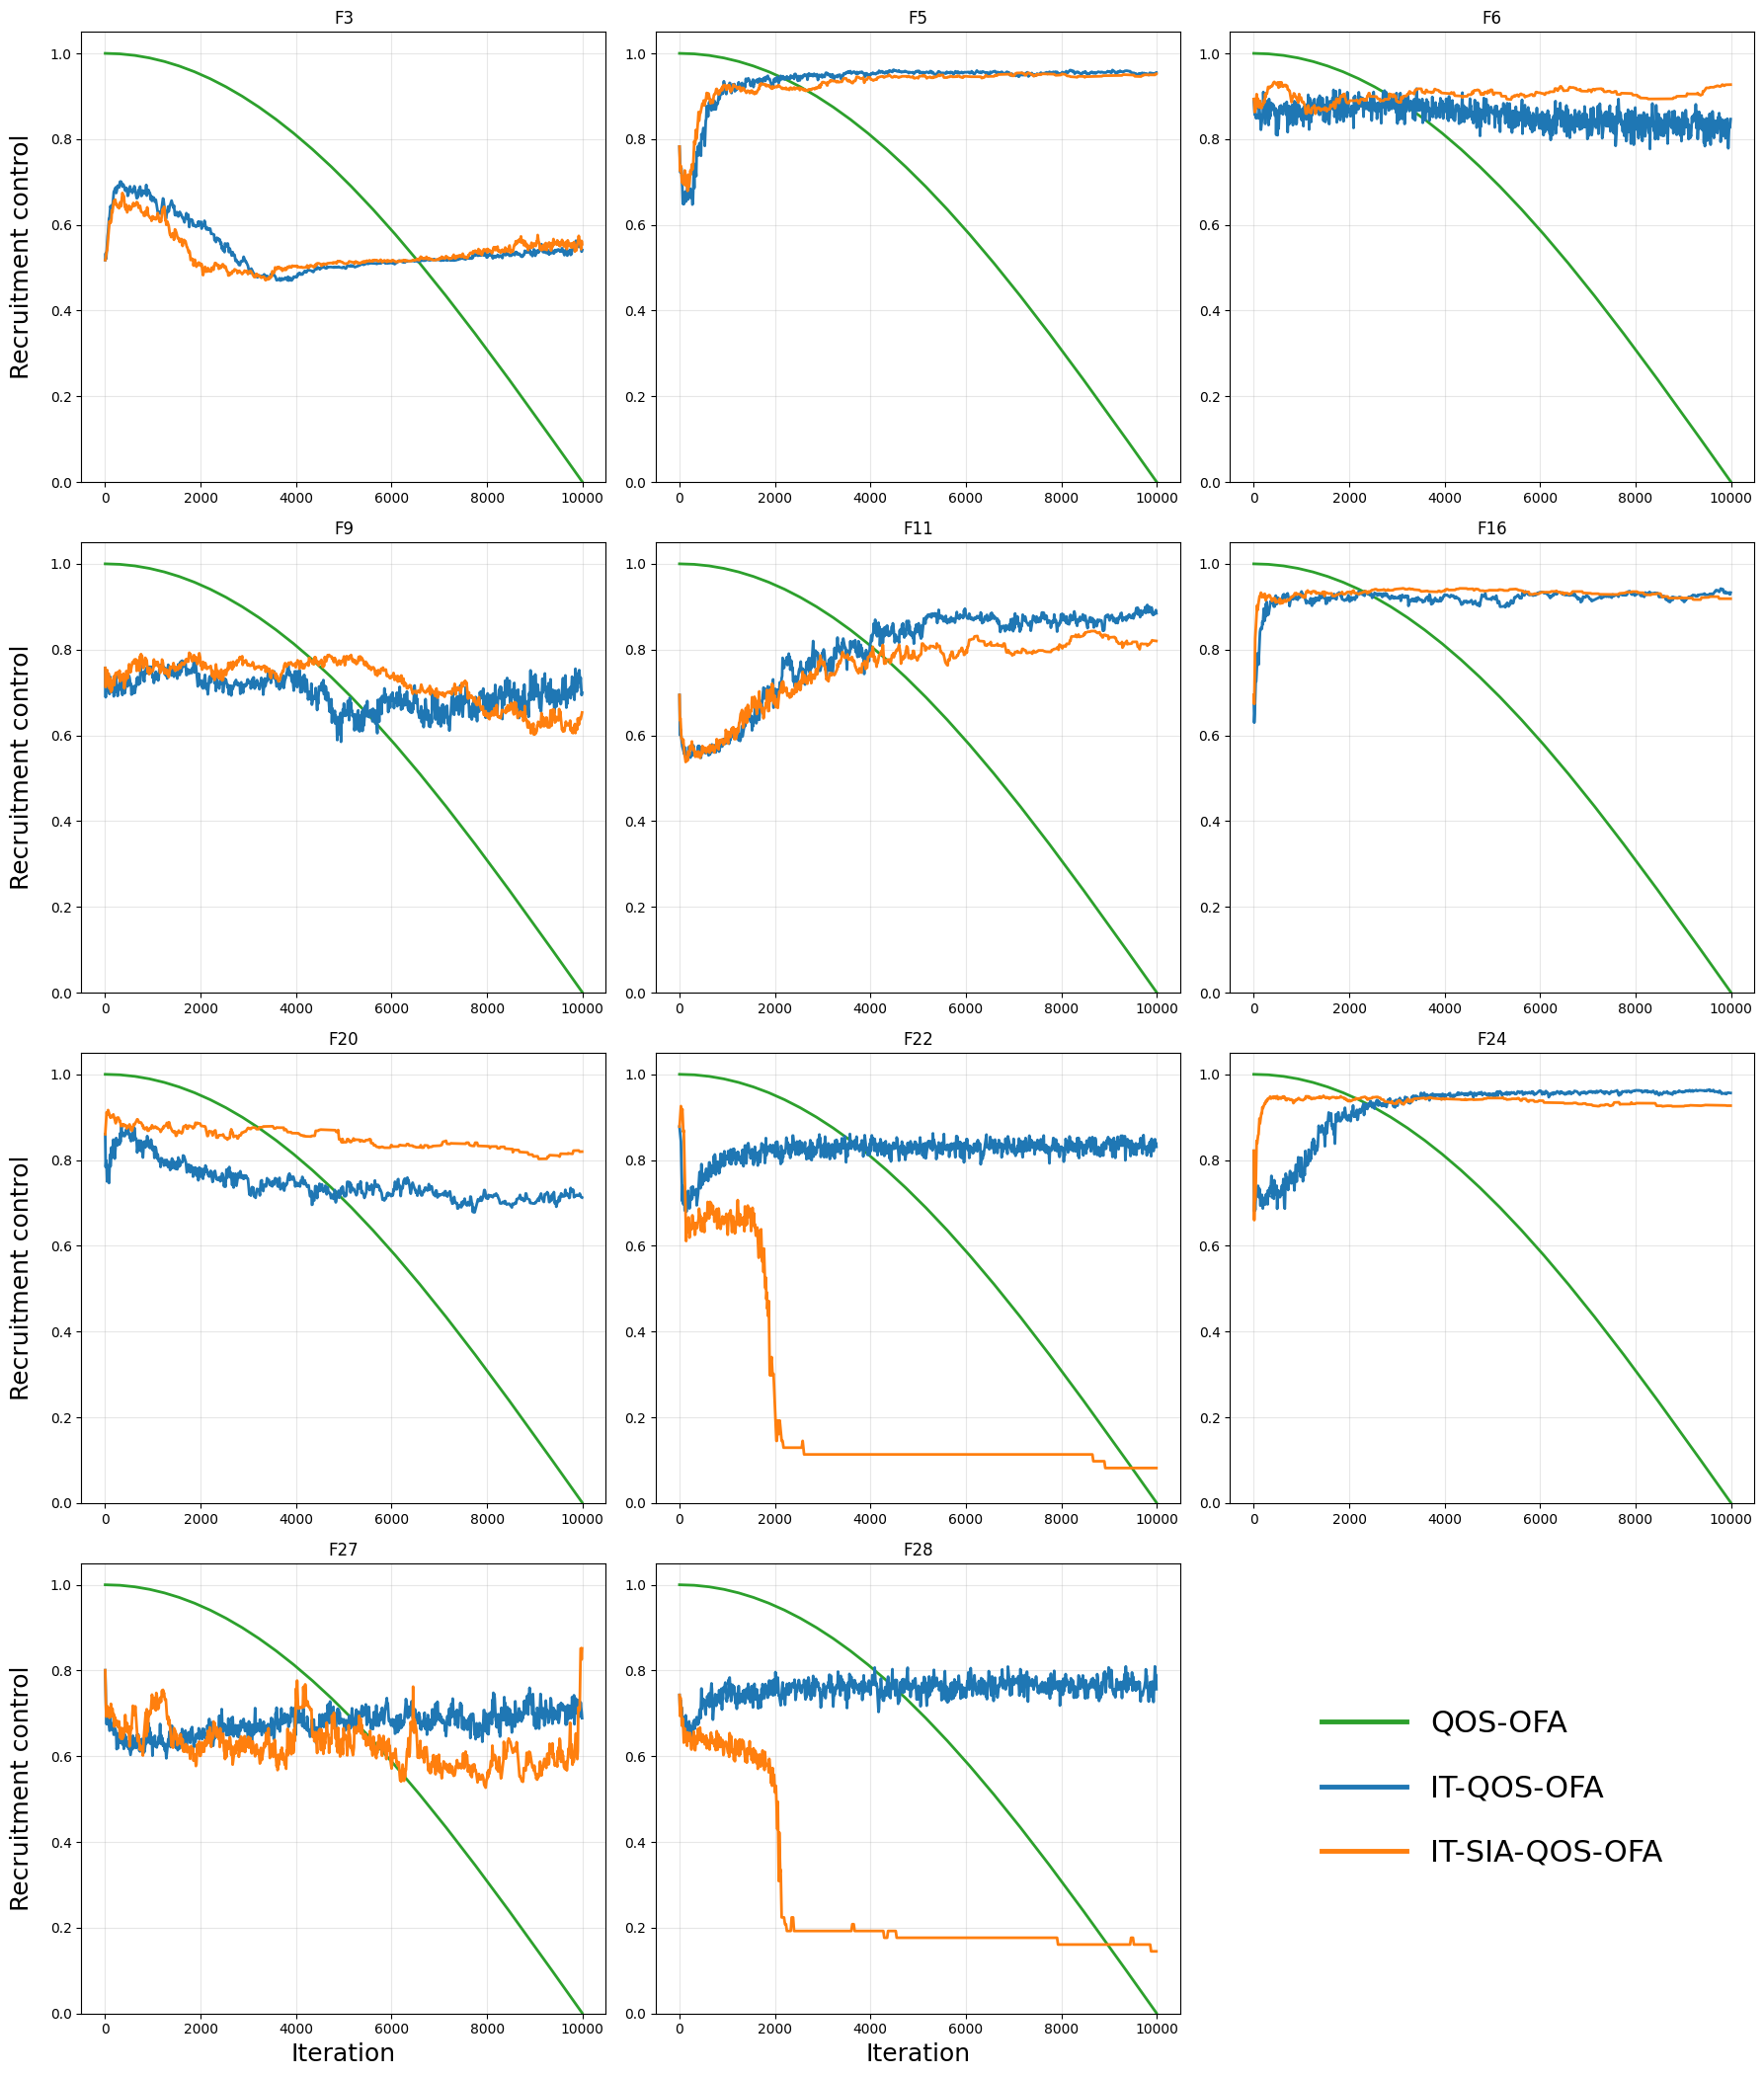

Saved SVG: Figures\recruitment_control_grid_11functions.svg


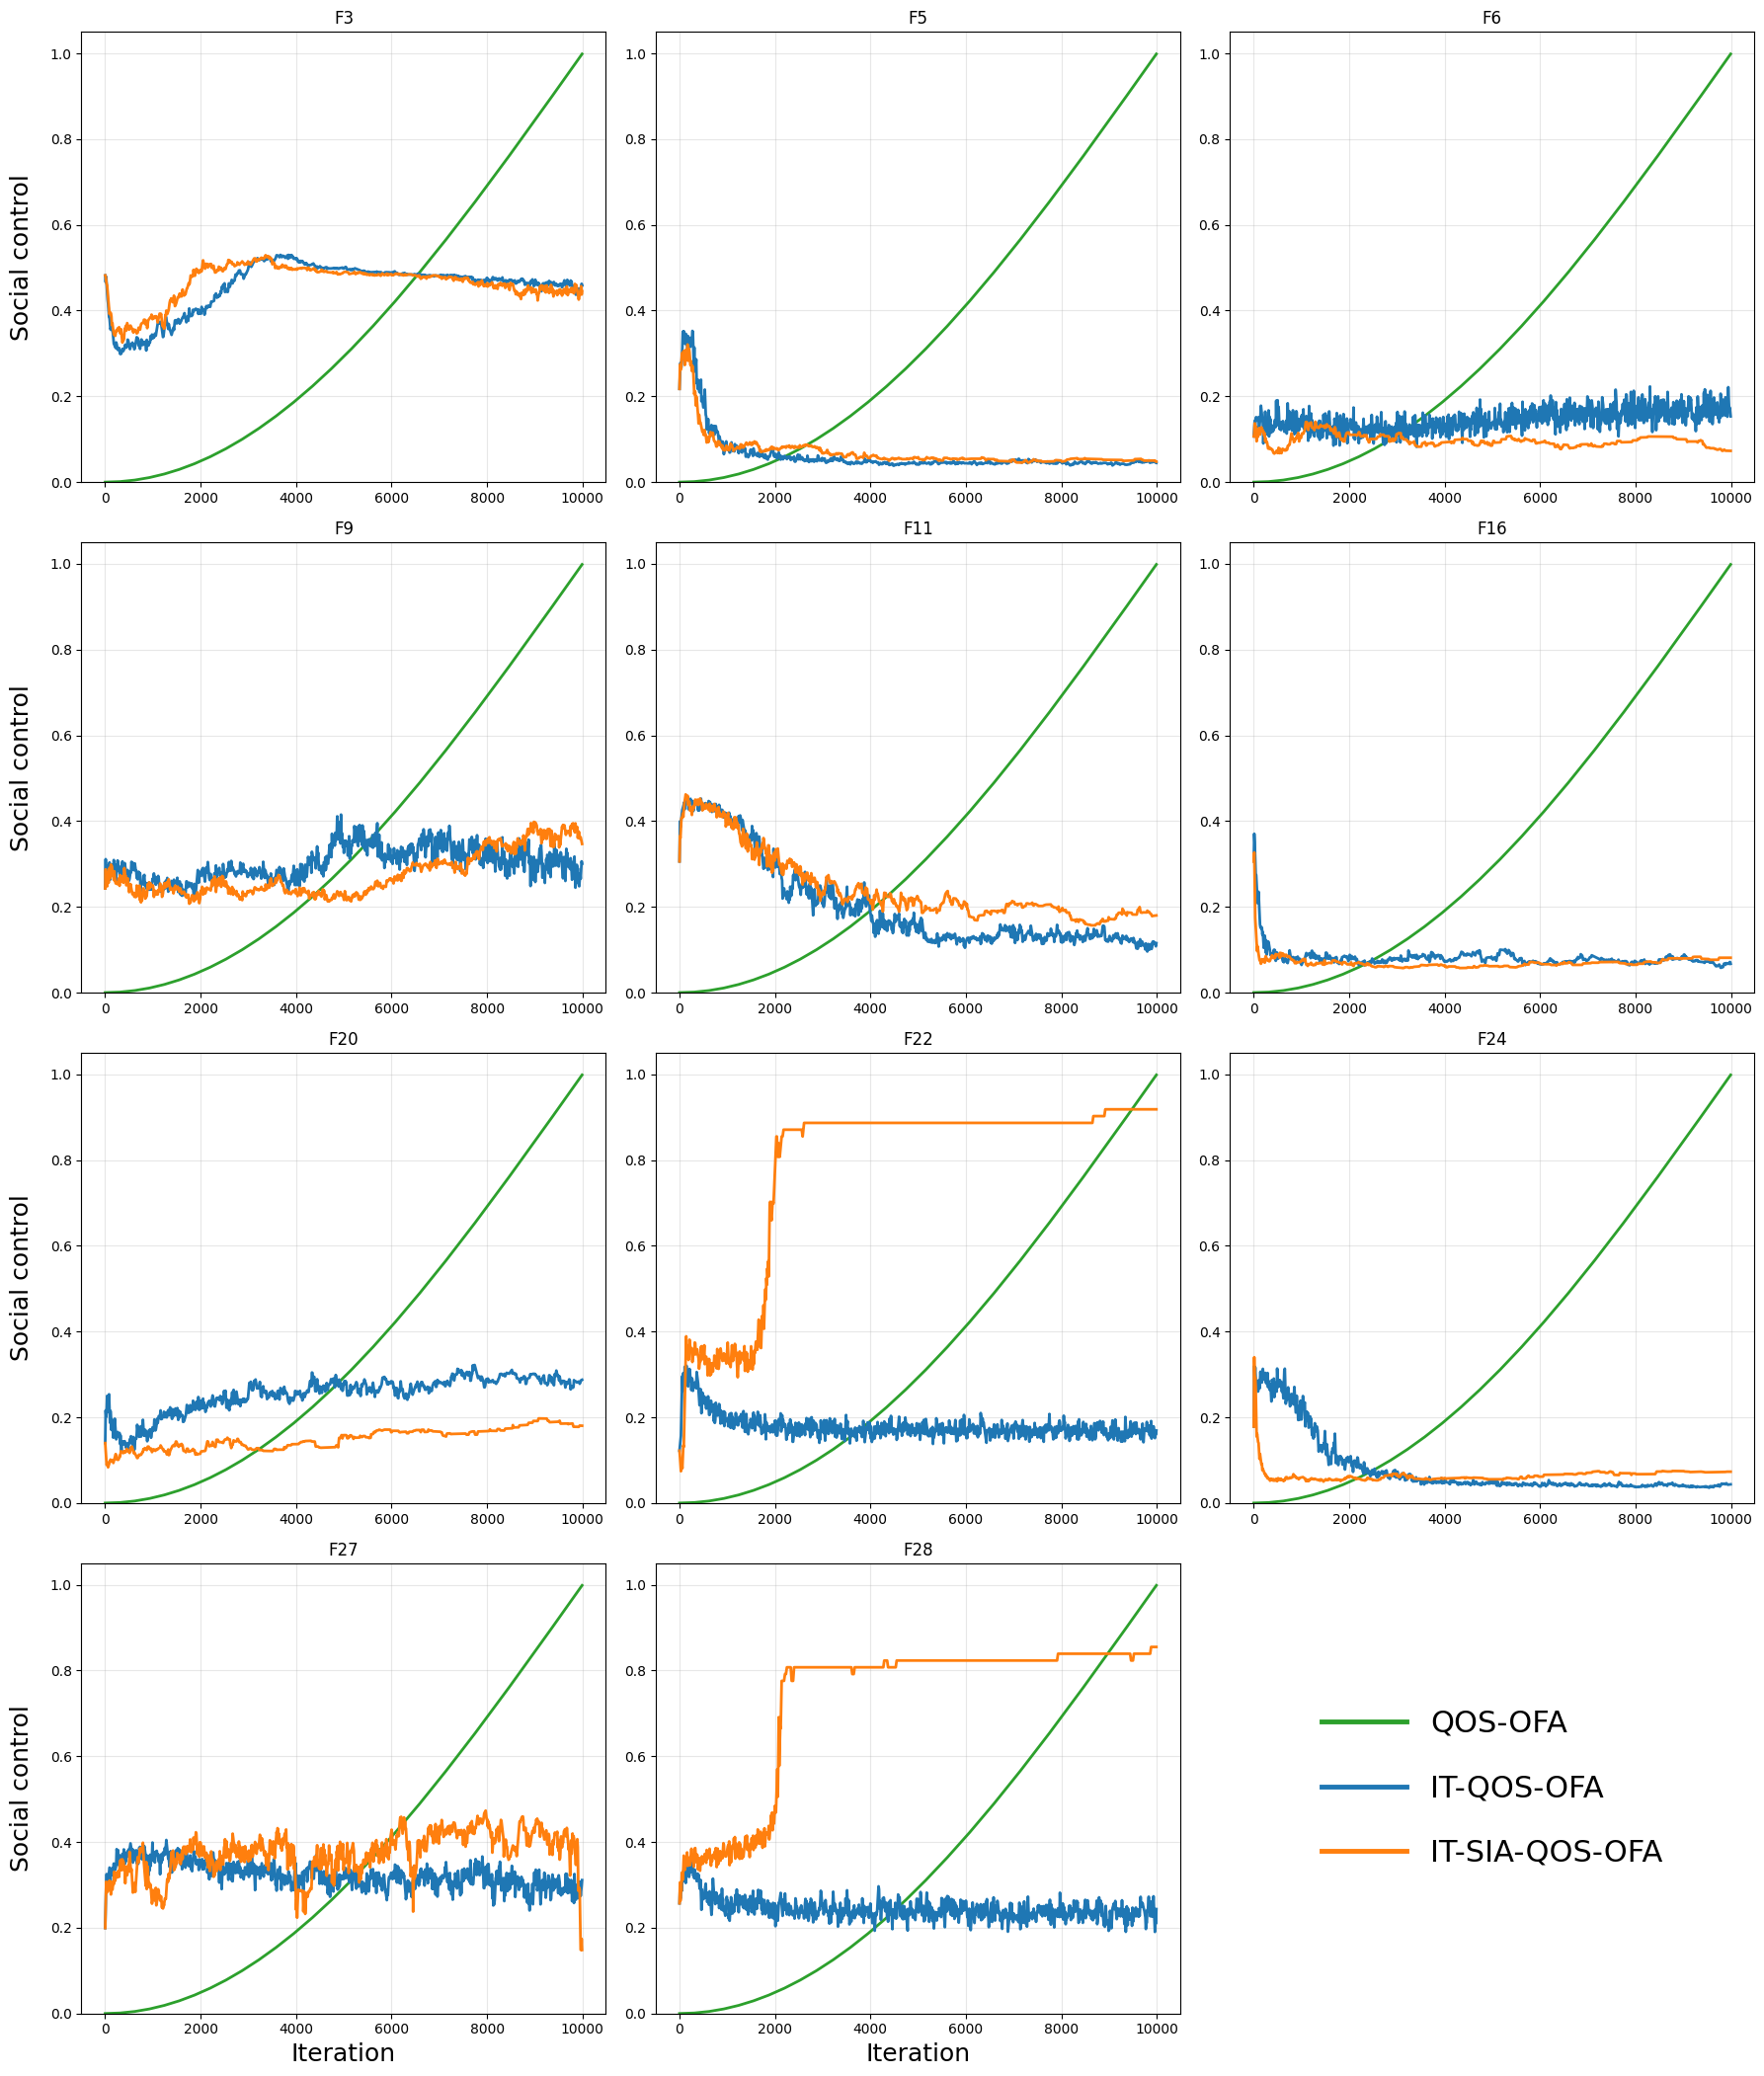

Saved SVG: Figures\social_control_grid_11functions.svg


In [ ]:
# Control behaviour grids
# 11 CEC functions + 1 legend subplot

RECRUITMENT_OUTPUT_PATH = Path("Figures/recruitment_control_grid_11functions.svg")
SOCIAL_OUTPUT_PATH = Path("Figures/social_control_grid_11functions.svg")

ALGORITHM_ORDER = ["QOS-OFA", "IT-QOS-OFA", "IT-SIA-QOS-OFA"]

# Enforced colors
ALGORITHM_COLORS = {"QOS-OFA": "tab:green", "IT-QOS-OFA": "tab:blue", "IT-SIA-QOS-OFA": "tab:orange"}
SVG_EVERY_N = 10

# Legend settings
LEGEND_FONTSIZE = 22
LEGEND_LINEWIDTH = 3.5

# Font sizes
TITLE_FONTSIZE = 12
XLABEL_FONTSIZE = 18
YLABEL_FONTSIZE = 18  
TICK_FONTSIZE = 10

# Keeps SVG text editable
plt.rcParams["svg.fonttype"] = "none"

# Helps simplify paths in SVG
plt.rcParams["path.simplify"] = True
plt.rcParams["path.simplify_threshold"] = 0.5

# Safety
if "combined_conv_df" not in globals():
    raise NameError("combined_conv_df does not exist. Load your convergence data first.")

required_cols = ["algorithm_label", "cec_func_num", "objective_name", "iteration","mean_temp_median"]
missing_cols = [c for c in required_cols if c not in combined_conv_df.columns]

if missing_cols:
    raise ValueError(
        f"Missing required columns in combined_conv_df: {missing_cols}\n\n"
        f"Available temperature columns:\n"
        f"{[c for c in combined_conv_df.columns if 'temp' in c]}"
    )

combined_control_df = combined_conv_df.copy()
combined_control_df["cec_func_num"] = combined_control_df["cec_func_num"].astype(int)

found_algorithms = set(combined_control_df["algorithm_label"].unique())
expected_algorithms = set(ALGORITHM_ORDER)

if found_algorithms != expected_algorithms:
    raise ValueError(f"Unexpected algorithms found.\n"f"Expected: {sorted(expected_algorithms)}\n"f"Found: {sorted(found_algorithms)}")

cec_functions = sorted(combined_control_df["cec_func_num"].dropna().unique())
T_TOTAL = combined_control_df["iteration"].max()

print("Algorithms:", sorted(found_algorithms))
print("CEC functions:", cec_functions)
print("Maximum iteration:", T_TOTAL)
print("SVG downsampling: plotting every", SVG_EVERY_N, "iterations")
print("Enforced colors:", ALGORITHM_COLORS)



# QOS-OFA control schedules
def qos_recruitment_schedule(iteration, T_total):
    return np.cos(0.5 * np.pi * iteration / T_total)


def qos_social_schedule(iteration, T_total):
    return 1.0 - qos_recruitment_schedule(iteration, T_total)

# Helper
def get_control_curve(df_alg, control_type, T_total):
    algorithm_label = df_alg["algorithm_label"].iloc[0]
    df_alg = df_alg.sort_values("iteration")
    df_alg = df_alg.iloc[::SVG_EVERY_N, :]
    x = df_alg["iteration"].to_numpy(dtype=float)

    if algorithm_label == "QOS-OFA":
        if control_type == "recruitment":
            y = qos_recruitment_schedule(x, T_total)
        elif control_type == "social":
            y = qos_social_schedule(x, T_total)
        else:
            raise ValueError("control_type must be 'recruitment' or 'social'")

    elif algorithm_label in ["IT-QOS-OFA", "IT-SIA-QOS-OFA"]:
        temp = df_alg["mean_temp_median"].to_numpy(dtype=float)
        if control_type == "recruitment":
            y = temp
        elif control_type == "social":
            y = 1.0 - temp
        else:
            raise ValueError("control_type must be 'recruitment' or 'social'")
    else:
        raise ValueError(f"Unknown algorithm label: {algorithm_label}")
    return x, y



# Plotting
def plot_control_grid(df,*,control_type,cec_functions,output_path,nrows=4,ncols=3,figsize=(18, 22)):
    if control_type not in ["recruitment", "social"]:
        raise ValueError("control_type must be 'recruitment' or 'social'")

    total_slots = nrows * ncols
    if len(cec_functions) > total_slots:
        raise ValueError(
            f"Need at least {len(cec_functions)} subplot slots, "
            f"but only {total_slots} are available."
        )

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()
    for idx, cec_func_num in enumerate(cec_functions):
        ax = axes[idx]
        df_func = df[df["cec_func_num"] == cec_func_num].copy()
        if df_func.empty:
            ax.axis("off")
            continue

        for algorithm_label in ALGORITHM_ORDER:
            df_alg = df_func[df_func["algorithm_label"] == algorithm_label].copy()
            if df_alg.empty:
                continue

            x, y = get_control_curve(df_alg=df_alg, control_type=control_type, T_total=T_TOTAL)
            ax.plot(x, y, linewidth=2, color=ALGORITHM_COLORS[algorithm_label], label=algorithm_label)

        ax.set_title(f"F{cec_func_num}", fontsize=TITLE_FONTSIZE)
        ax.set_ylim(0, 1.05)

        if idx // ncols == nrows - 1:
            ax.set_xlabel("Iteration", fontsize=XLABEL_FONTSIZE)
        else:
            ax.set_xlabel("")

        if idx % ncols == 0:
            if control_type == "recruitment":
                ax.set_ylabel("Recruitment control", fontsize=YLABEL_FONTSIZE, labelpad=12)
            else:
                ax.set_ylabel("Social control", fontsize=YLABEL_FONTSIZE, labelpad=12)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for j in range(len(cec_functions), total_slots):
        axes[j].axis("off")

    # Put shared legend in final subplot
    legend_ax = axes[total_slots - 1]
    legend_ax.axis("off")
    legend_handles = [
        Line2D([0],[0],color=ALGORITHM_COLORS[algorithm_label],linewidth=LEGEND_LINEWIDTH,label=algorithm_label)
        for algorithm_label in ALGORITHM_ORDER
    ]

    legend_ax.legend(handles=legend_handles, loc="center", frameon=False, fontsize=LEGEND_FONTSIZE, handlelength=2.8, labelspacing=1.2)
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(output_path, bbox_inches="tight", format="svg")
    plt.show()

    print(f"Saved SVG: {output_path}")

    return fig

# Running both figures
fig_recruitment = plot_control_grid(combined_control_df,control_type="recruitment",cec_functions=cec_functions,output_path=RECRUITMENT_OUTPUT_PATH,nrows=4,ncols=3,figsize=(18, 22))
fig_social = plot_control_grid(combined_control_df,control_type="social",cec_functions=cec_functions,output_path=SOCIAL_OUTPUT_PATH,nrows=4,ncols=3,figsize=(18, 22))

Algorithms: ['IT-QOS-OFA', 'IT-SIA-QOS-OFA', 'QOS-OFA']
CEC functions: [np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(16), np.int64(20), np.int64(22), np.int64(24), np.int64(27), np.int64(28)]
Maximum iteration: 10000
Plotted column: acceptance_rate_median
SVG downsampling: plotting every 10 iterations
Enforced colors: {'QOS-OFA': 'tab:green', 'IT-QOS-OFA': 'tab:blue', 'IT-SIA-QOS-OFA': 'tab:orange'}

Available acceptance-rate columns:
['acceptance_rate_mean', 'acceptance_rate_std', 'acceptance_rate_median', 'acceptance_rate_q25', 'acceptance_rate_q75', 'worse_acceptance_rate_mean', 'worse_acceptance_rate_std', 'worse_acceptance_rate_median', 'worse_acceptance_rate_q25', 'worse_acceptance_rate_q75']


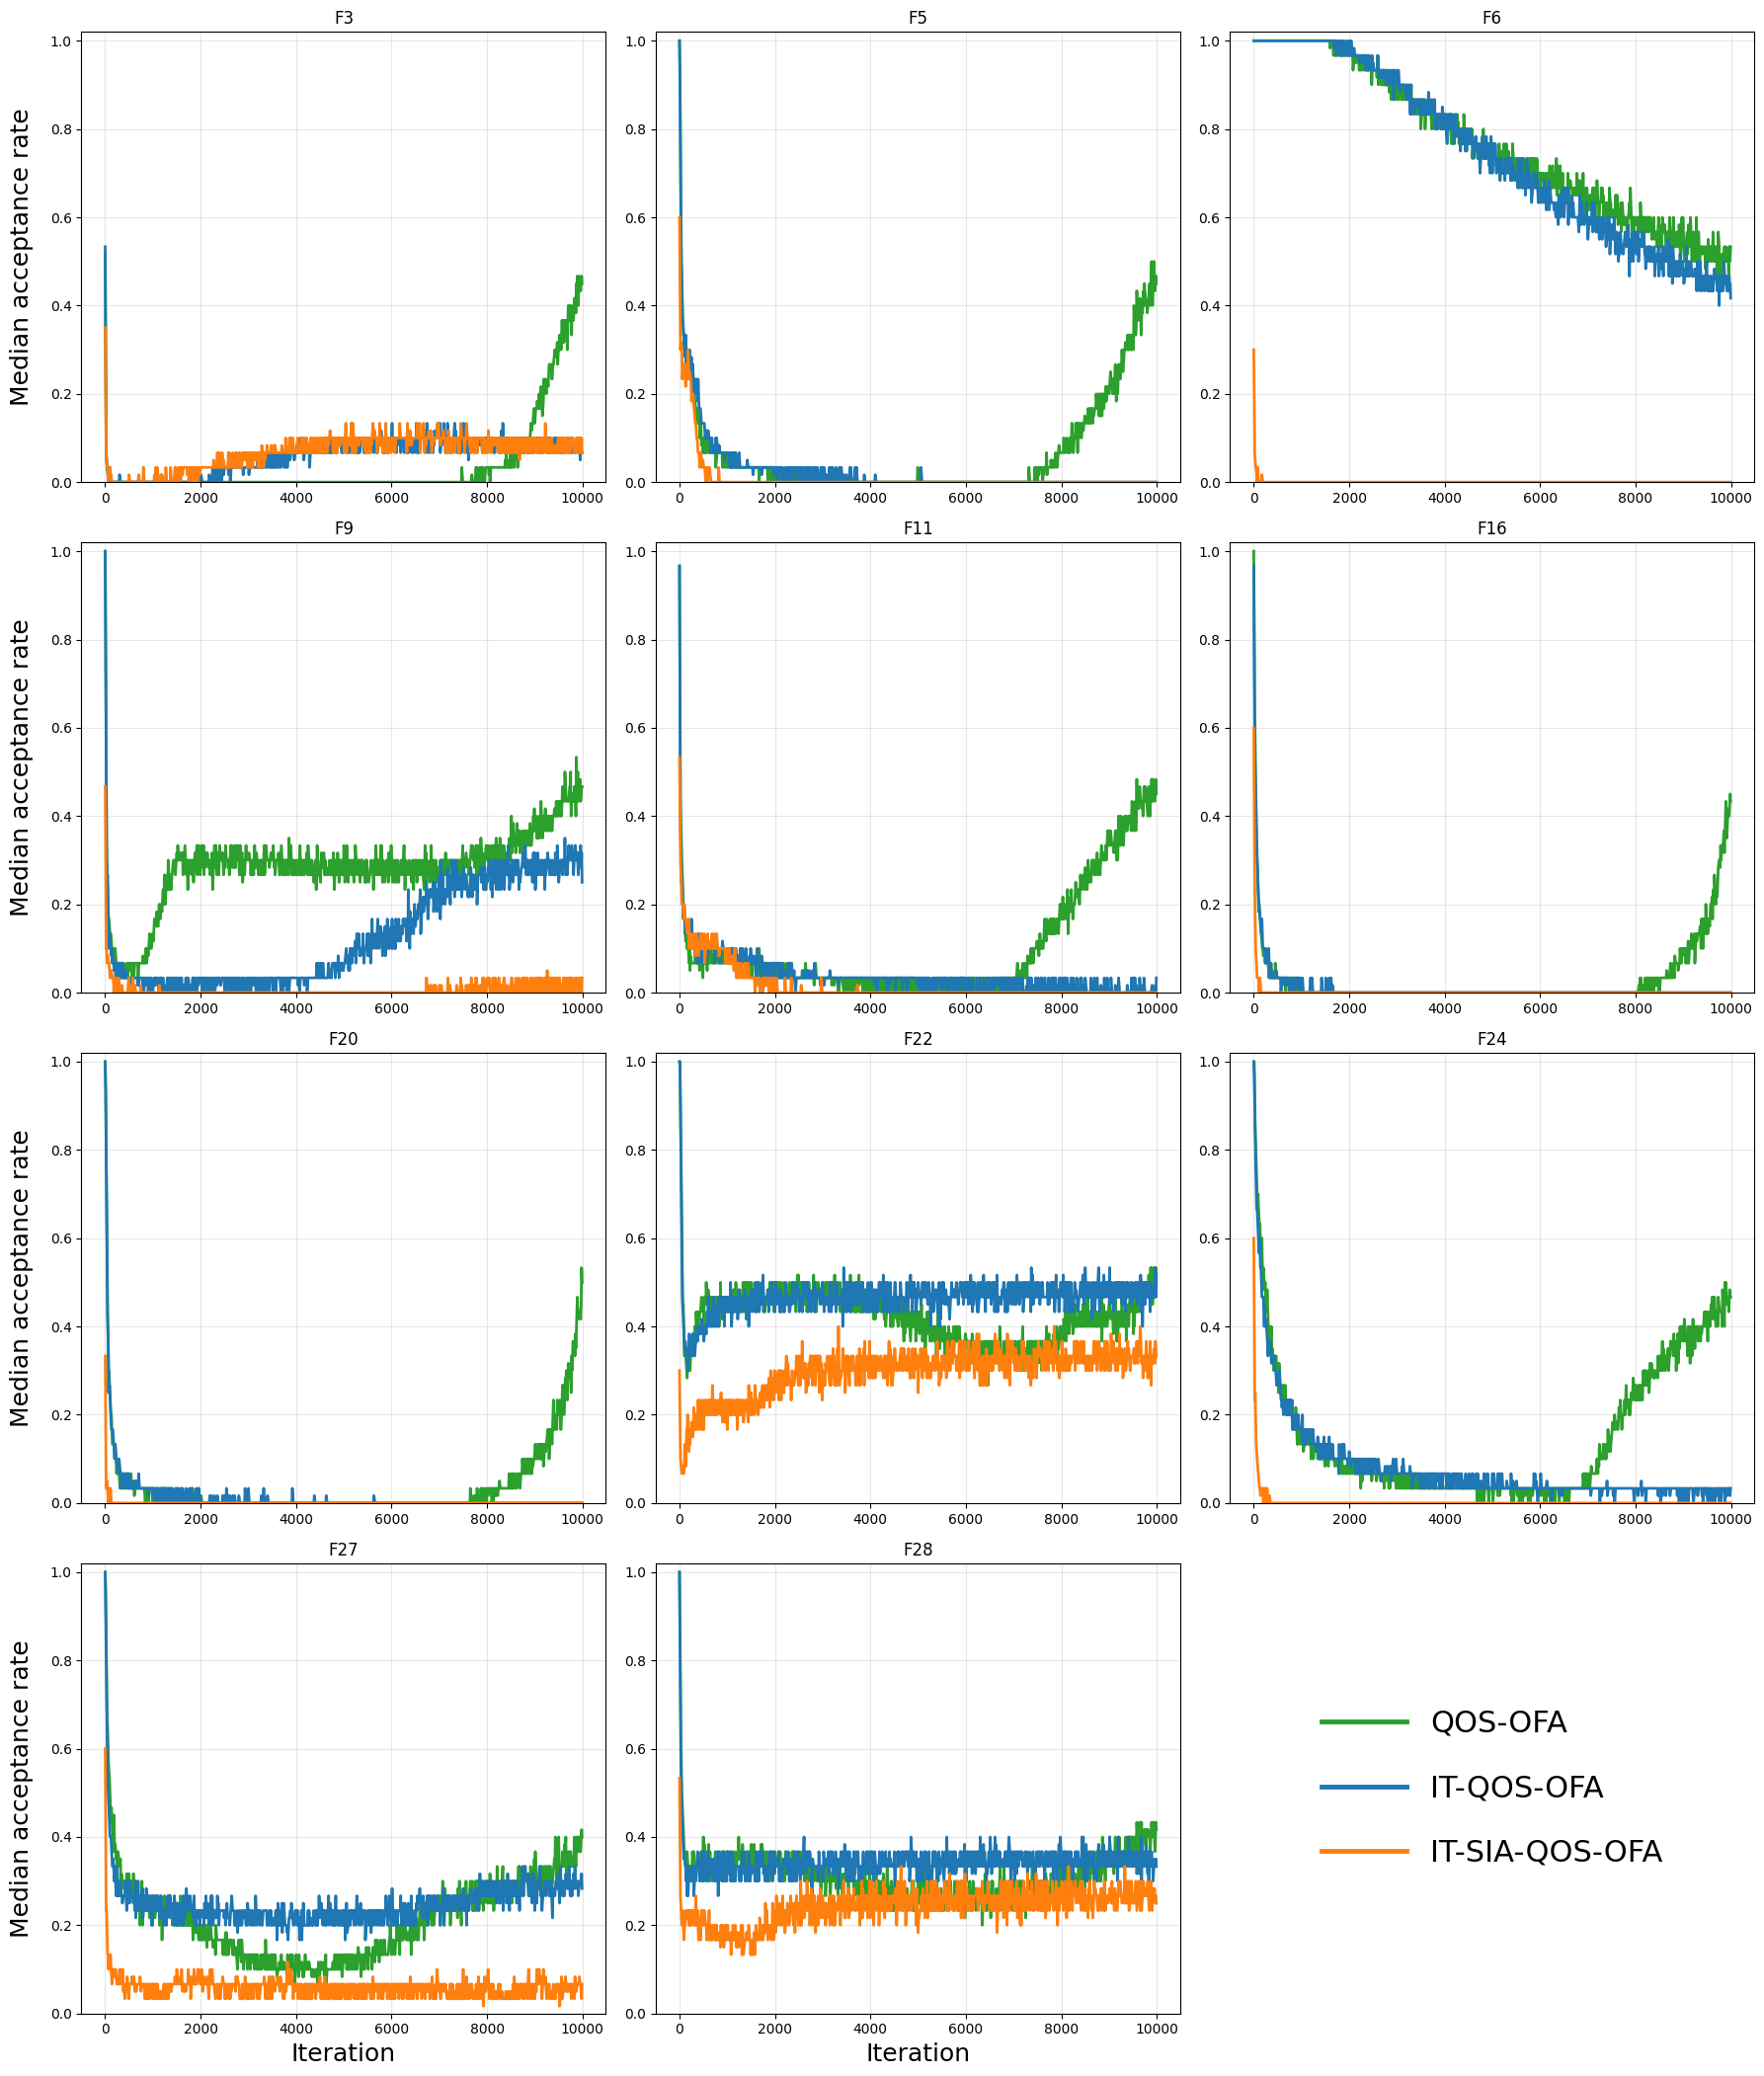

Saved SVG: Figures\acceptance_rate_grid_11functions.svg


In [ ]:
# Acceptance rate grid:
CONVERGENCE_SHEET = "convergence_all"
ACCEPTANCE_METRIC = "acceptance_rate"
Y_COL = f"{ACCEPTANCE_METRIC}_median"

OUTPUT_PATH = Path("Figures/acceptance_rate_grid_11functions.svg")

ALGORITHM_ORDER = ["QOS-OFA", "IT-QOS-OFA", "IT-SIA-QOS-OFA"]

# Enforced colors
ALGORITHM_COLORS = {"QOS-OFA": "tab:green","IT-QOS-OFA": "tab:blue","IT-SIA-QOS-OFA": "tab:orange"}
SVG_EVERY_N = 10

LEGEND_FONTSIZE = 22
LEGEND_LINEWIDTH = 3.5

# Font sizes
TITLE_FONTSIZE = 12
XLABEL_FONTSIZE = 18
YLABEL_FONTSIZE = 18
TICK_FONTSIZE = 10

USE_LOG_Y = False
INCLUDE_IQR = False

# Keeps SVG text editable
plt.rcParams["svg.fonttype"] = "none"

# Helps simplify paths in SVG
plt.rcParams["path.simplify"] = True
plt.rcParams["path.simplify_threshold"] = 0.5



# Loading data from convergence
acceptance_parts = []

for algorithm_label, path in algorithm_files.items():
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find convergence workbook: {path.resolve()}")

    xls = pd.ExcelFile(path)
    if CONVERGENCE_SHEET not in xls.sheet_names:
        raise ValueError(f"Sheet '{CONVERGENCE_SHEET}' not found in {path}.\n"f"Available sheets: {xls.sheet_names}")

    df = pd.read_excel(path, sheet_name=CONVERGENCE_SHEET)
    df["algorithm_label"] = algorithm_label
    df["source_file"] = str(path)
    acceptance_parts.append(df)

combined_acceptance_df = pd.concat(acceptance_parts, ignore_index=True)
# Safety
required_cols = ["algorithm_label", "cec_func_num", "objective_name", "iteration",Y_COL]

missing_cols = [c for c in required_cols if c not in combined_acceptance_df.columns]
if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}\n\n"
        f"Available acceptance columns:\n"
        f"{[c for c in combined_acceptance_df.columns if 'acceptance' in c]}"
    )

combined_acceptance_df["cec_func_num"] = (combined_acceptance_df["cec_func_num"].astype(int))
expected_algorithms = set(ALGORITHM_ORDER)
found_algorithms = set(combined_acceptance_df["algorithm_label"].unique())

if found_algorithms != expected_algorithms:
    raise ValueError(
        f"Unexpected algorithms found.\n"
        f"Expected: {sorted(expected_algorithms)}\n"
        f"Found: {sorted(found_algorithms)}"
    )

cec_functions = sorted(combined_acceptance_df["cec_func_num"].dropna().unique())
print("Algorithms:", sorted(found_algorithms))
print("CEC functions:", cec_functions)
print("Maximum iteration:", combined_acceptance_df["iteration"].max())
print("Plotted column:", Y_COL)
print("SVG downsampling: plotting every", SVG_EVERY_N, "iterations")
print("Enforced colors:", ALGORITHM_COLORS)

print("\nAvailable acceptance-rate columns:")
print([c for c in combined_acceptance_df.columns if ACCEPTANCE_METRIC in c])


# Plotting
def plot_acceptance_rate_grid(df,*,cec_functions,output_path,use_log_y=False,include_iqr=False,nrows=4,ncols=3,figsize=(18, 22)):
    """
    Creates a 4x3 grid:
    - 11 subplots for CEC functions

    Each line shows acceptance_rate_median, i.e. the median acceptance rate
    across 30 seeded runs at each iteration.
    """

    total_slots = nrows * ncols
    if len(cec_functions) > total_slots:
        raise ValueError(f"Need at least {len(cec_functions)} subplot slots, "f"but only {total_slots} are available.")

    q25_col = f"{ACCEPTANCE_METRIC}_q25"
    q75_col = f"{ACCEPTANCE_METRIC}_q75"
    if q25_col not in df.columns:
        q25_col = None

    if q75_col not in df.columns:
        q75_col = None

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()
    global_y_max = df[Y_COL].max()

    for idx, cec_func_num in enumerate(cec_functions):
        ax = axes[idx]
        df_func = df[df["cec_func_num"] == cec_func_num].copy()

        if df_func.empty:
            ax.axis("off")
            continue

        for algorithm_label in ALGORITHM_ORDER:
            df_alg = df_func[df_func["algorithm_label"] == algorithm_label].copy()
            if df_alg.empty:
                continue

            df_alg = df_alg.sort_values("iteration")

            # Downsample only for SVG size/speed
            df_alg_svg = df_alg.iloc[::SVG_EVERY_N, :]
            x = df_alg_svg["iteration"].to_numpy(dtype=float)
            y = df_alg_svg[Y_COL].to_numpy(dtype=float)

            if use_log_y:
                y = np.maximum(y, 1e-12)

            ax.plot(x, y, linewidth=2, color=ALGORITHM_COLORS[algorithm_label], label=algorithm_label)

            if include_iqr and q25_col is not None and q75_col is not None:
                q25 = df_alg_svg[q25_col].to_numpy(dtype=float)
                q75 = df_alg_svg[q75_col].to_numpy(dtype=float)
                if use_log_y:
                    q25 = np.maximum(q25, 1e-12)
                    q75 = np.maximum(q75, 1e-12)

                ax.fill_between(x,q25,q75,color=ALGORITHM_COLORS[algorithm_label],alpha=0.12)

        if use_log_y:
            ax.set_yscale("log")
        else:
            if global_y_max <= 1.05:
                ax.set_ylim(0, 1.02)

        ax.set_title(f"F{cec_func_num}", fontsize=TITLE_FONTSIZE)

        if idx // ncols == nrows - 1:
            ax.set_xlabel("Iteration", fontsize=XLABEL_FONTSIZE)
        else:
            ax.set_xlabel("")

        if idx % ncols == 0:
            ax.set_ylabel("Median acceptance rate", fontsize=YLABEL_FONTSIZE, labelpad=12)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
        ax.grid(True, alpha=0.3)

    for j in range(len(cec_functions), total_slots):
        axes[j].axis("off")

    # Use the last empty subplot as the shared legend
    legend_ax = axes[total_slots - 1]
    legend_ax.axis("off")

    legend_handles = [
        Line2D([0],[0],color=ALGORITHM_COLORS[algorithm_label],linewidth=LEGEND_LINEWIDTH,label=algorithm_label)
        for algorithm_label in ALGORITHM_ORDER
    ]

    legend_ax.legend(handles=legend_handles,loc="center",frameon=False,fontsize=LEGEND_FONTSIZE,handlelength=2.8,labelspacing=1.2)
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight", format="svg")
    plt.show()
    print(f"Saved SVG: {output_path}")

    return fig

fig = plot_acceptance_rate_grid(combined_acceptance_df,cec_functions=cec_functions,output_path=OUTPUT_PATH,use_log_y=USE_LOG_Y,include_iqr=INCLUDE_IQR,nrows=4,ncols=3,figsize=(18, 22))

Algorithms: ['IT-QOS-OFA', 'IT-SIA-QOS-OFA', 'QOS-OFA']
CEC functions: [np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(16), np.int64(20), np.int64(22), np.int64(24), np.int64(27), np.int64(28)]
Maximum iteration: 10000
Plotted column: diversity_pos_median
SVG downsampling: plotting every 10 iterations
Enforced colors: {'QOS-OFA': 'tab:green', 'IT-QOS-OFA': 'tab:blue', 'IT-SIA-QOS-OFA': 'tab:orange'}

Available population-spread columns:
['diversity_pos_mean', 'diversity_pos_std', 'diversity_pos_median', 'diversity_pos_q25', 'diversity_pos_q75']


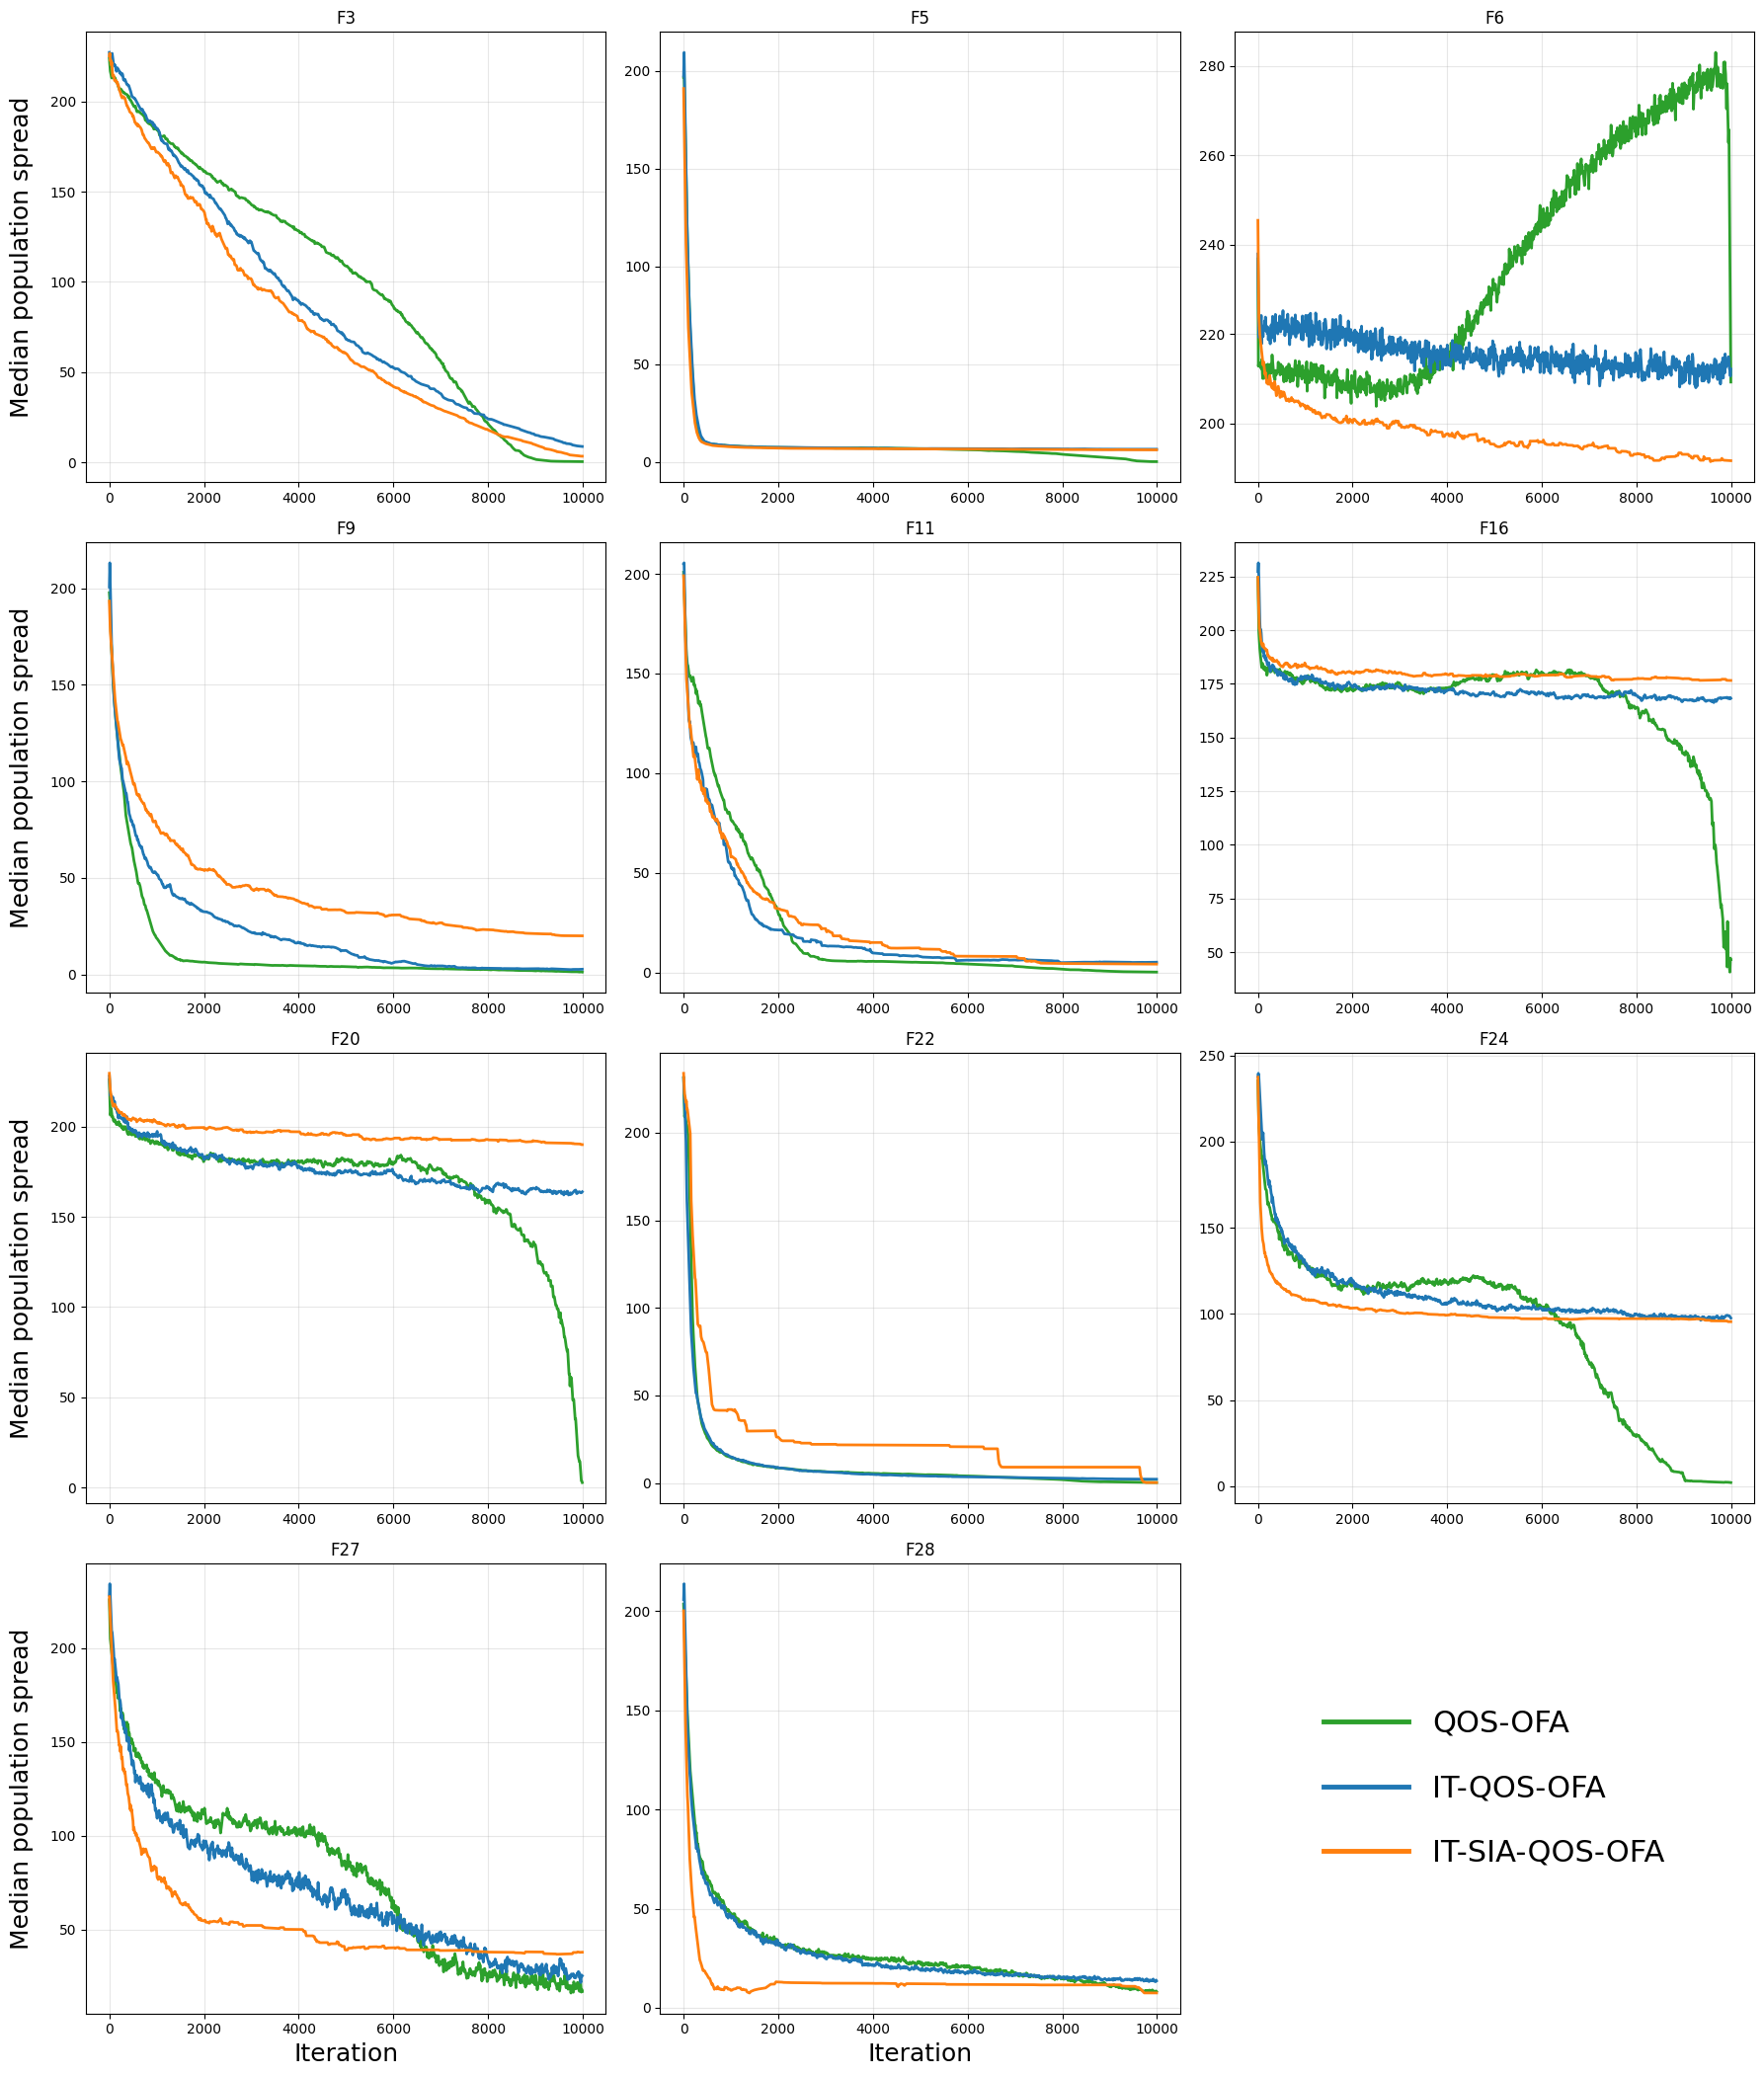

Saved SVG: Figures\population_spread_grid_11functions.svg


In [ ]:
# Population spread grid:
CONVERGENCE_SHEET = "convergence_all"
POP_SPREAD_METRIC = "diversity_pos"
Y_COL = f"{POP_SPREAD_METRIC}_median"

OUTPUT_PATH = Path("Figures/population_spread_grid_11functions.svg")

ALGORITHM_ORDER = ["QOS-OFA", "IT-QOS-OFA", "IT-SIA-QOS-OFA"]

# Enforced colors
ALGORITHM_COLORS = {"QOS-OFA": "tab:green","IT-QOS-OFA": "tab:blue","IT-SIA-QOS-OFA": "tab:orange"}
SVG_EVERY_N = 10

LEGEND_FONTSIZE = 22
LEGEND_LINEWIDTH = 3.5

# Font sizes
TITLE_FONTSIZE = 12
XLABEL_FONTSIZE = 18
YLABEL_FONTSIZE = 18
TICK_FONTSIZE = 10

USE_LOG_Y = False
INCLUDE_IQR = False

# Keeps SVG text editable
plt.rcParams["svg.fonttype"] = "none"

# Helps simplify paths in SVG
plt.rcParams["path.simplify"] = True
plt.rcParams["path.simplify_threshold"] = 0.5



# Loading data from convergence
convergence_parts = []

for algorithm_label, path in algorithm_files.items():
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find convergence workbook: {path.resolve()}")

    xls = pd.ExcelFile(path)
    if CONVERGENCE_SHEET not in xls.sheet_names:
        raise ValueError(f"Sheet '{CONVERGENCE_SHEET}' not found in {path}.\n"f"Available sheets: {xls.sheet_names}")

    df = pd.read_excel(path, sheet_name=CONVERGENCE_SHEET)
    df["algorithm_label"] = algorithm_label
    df["source_file"] = str(path)
    convergence_parts.append(df)

combined_population_df = pd.concat(convergence_parts, ignore_index=True)

# Safety
required_cols = ["algorithm_label", "cec_func_num", "objective_name", "iteration",Y_COL]

missing_cols = [c for c in required_cols if c not in combined_population_df.columns]
if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}\n\n"
        f"Available diversity columns:\n"
        f"{[c for c in combined_population_df.columns if 'diversity' in c]}"
    )

combined_population_df["cec_func_num"] = (combined_population_df["cec_func_num"].astype(int))
expected_algorithms = set(ALGORITHM_ORDER)
found_algorithms = set(combined_population_df["algorithm_label"].unique())

if found_algorithms != expected_algorithms:
    raise ValueError(
        f"Unexpected algorithms found.\n"
        f"Expected: {sorted(expected_algorithms)}\n"
        f"Found: {sorted(found_algorithms)}"
    )

cec_functions = sorted(combined_population_df["cec_func_num"].dropna().unique())
print("Algorithms:", sorted(found_algorithms))
print("CEC functions:", cec_functions)
print("Maximum iteration:", combined_population_df["iteration"].max())
print("Plotted column:", Y_COL)
print("SVG downsampling: plotting every", SVG_EVERY_N, "iterations")
print("Enforced colors:", ALGORITHM_COLORS)

print("\nAvailable population-spread columns:")
print([c for c in combined_population_df.columns if POP_SPREAD_METRIC in c])


# Plotting
def plot_population_spread_grid(df,*,cec_functions,output_path,use_log_y=False,include_iqr=False,nrows=4,ncols=3,figsize=(18, 22)):
    """
    Creates a 4x3 grid:
    - 11 subplots for CEC functions

    Each line shows diversity_pos_median, i.e. the median population spread
    across 30 seeded runs at each iteration.
    """

    total_slots = nrows * ncols
    if len(cec_functions) > total_slots:
        raise ValueError(f"Need at least {len(cec_functions)} subplot slots, "f"but only {total_slots} are available.")

    q25_col = f"{POP_SPREAD_METRIC}_q25"
    q75_col = f"{POP_SPREAD_METRIC}_q75"
    if q25_col not in df.columns:
        q25_col = None

    if q75_col not in df.columns:
        q75_col = None

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for idx, cec_func_num in enumerate(cec_functions):
        ax = axes[idx]
        df_func = df[df["cec_func_num"] == cec_func_num].copy()

        if df_func.empty:
            ax.axis("off")
            continue

        for algorithm_label in ALGORITHM_ORDER:
            df_alg = df_func[df_func["algorithm_label"] == algorithm_label].copy()
            if df_alg.empty:
                continue

            df_alg = df_alg.sort_values("iteration")

            # Downsample only for SVG size/speed
            df_alg_svg = df_alg.iloc[::SVG_EVERY_N, :]
            x = df_alg_svg["iteration"].to_numpy(dtype=float)
            y = df_alg_svg[Y_COL].to_numpy(dtype=float)

            if use_log_y:
                y = np.maximum(y, 1e-12)

            ax.plot(x, y, linewidth=2, color=ALGORITHM_COLORS[algorithm_label], label=algorithm_label)

            if include_iqr and q25_col is not None and q75_col is not None:
                q25 = df_alg_svg[q25_col].to_numpy(dtype=float)
                q75 = df_alg_svg[q75_col].to_numpy(dtype=float)
                if use_log_y:
                    q25 = np.maximum(q25, 1e-12)
                    q75 = np.maximum(q75, 1e-12)

                ax.fill_between(x,q25,q75,color=ALGORITHM_COLORS[algorithm_label],alpha=0.12)

        if use_log_y:
            ax.set_yscale("log")

        ax.set_title(f"F{cec_func_num}", fontsize=TITLE_FONTSIZE)

        if idx // ncols == nrows - 1:
            ax.set_xlabel("Iteration", fontsize=XLABEL_FONTSIZE)
        else:
            ax.set_xlabel("")

        if idx % ncols == 0:
            ax.set_ylabel("Median population spread", fontsize=YLABEL_FONTSIZE, labelpad=12)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
        ax.grid(True, alpha=0.3)

    for j in range(len(cec_functions), total_slots):
        axes[j].axis("off")

    # Use the last empty subplot as the shared legend
    legend_ax = axes[total_slots - 1]
    legend_ax.axis("off")

    legend_handles = [
        Line2D([0],[0],color=ALGORITHM_COLORS[algorithm_label],linewidth=LEGEND_LINEWIDTH,label=algorithm_label)
        for algorithm_label in ALGORITHM_ORDER
    ]

    legend_ax.legend(handles=legend_handles,loc="center",frameon=False,fontsize=LEGEND_FONTSIZE,handlelength=2.8,labelspacing=1.2)
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight", format="svg")
    plt.show()
    print(f"Saved SVG: {output_path}")

    return fig

fig = plot_population_spread_grid(combined_population_df,cec_functions=cec_functions,output_path=OUTPUT_PATH,use_log_y=USE_LOG_Y,include_iqr=INCLUDE_IQR,nrows=4,ncols=3,figsize=(18, 22))

In [ ]:
def pick_x_column(df):
    return "iteration"


def resolve_metric_columns(df, base_metric):
    y_col = f"{base_metric}_median"
    q25_col = f"{base_metric}_q25"
    q75_col = f"{base_metric}_q75"

    if y_col not in df.columns:
        raise ValueError(
            f"Missing column: {y_col}\n"
            f"Available matching columns:\n"
            f"{[c for c in df.columns if base_metric in c]}"
        )

    if q25_col not in df.columns:
        q25_col = None

    if q75_col not in df.columns:
        q75_col = None

    return y_col, q25_col, q75_col

In [ ]:
# Final best-so-far CEC error table at T=10,000 for Appendix
TARGET_ITERATION = 10000
required_cols = ["algorithm_label", "cec_func_num", "objective_name", "iteration", "best_error_so_far_median"]

missing_cols = [c for c in required_cols if c not in combined_conv_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")


# Final iteration
df_final_10000 = combined_conv_df[combined_conv_df["iteration"] == TARGET_ITERATION].copy()

print(f"Rows at iteration {TARGET_ITERATION}:", len(df_final_10000))
print("Algorithms:", sorted(df_final_10000["algorithm_label"].unique()))
print("Functions:", sorted(df_final_10000["cec_func_num"].unique()))

# Safety
expected_rows = 3 * 11

if len(df_final_10000) != expected_rows:
    print(f"Warning: expected {expected_rows} rows, "f"but found {len(df_final_10000)} rows.")


# Long table
final_best_so_far_10000_long = (df_final_10000[required_cols].sort_values(["cec_func_num", "algorithm_label"]).reset_index(drop=True))


# Appendix table
final_best_so_far_10000_table = final_best_so_far_10000_long.pivot_table(
    index=["cec_func_num", "objective_name"],columns="algorithm_label",values="best_error_so_far_median",aggfunc="first"
).reset_index()

final_best_so_far_10000_table = final_best_so_far_10000_table.rename(columns={"cec_func_num": "Function","objective_name": "Objective"})

preferred_order = ["Function", "Objective", "QOS-OFA", "IT-QOS-OFA", "IT-SIA-QOS-OFA"]

final_best_so_far_10000_table = final_best_so_far_10000_table[[c for c in preferred_order if c in final_best_so_far_10000_table.columns]]
display(final_best_so_far_10000_table)


# Saving Excel
OUTPUT_EXCEL = Path("appendix_final_best_so_far_T10000.xlsx")

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    final_best_so_far_10000_long.to_excel(writer,sheet_name="long_table",index=False)
    final_best_so_far_10000_table.to_excel(writer,sheet_name="appendix_table",index=False)

print(f"Saved T={TARGET_ITERATION} appendix Excel table to: {OUTPUT_EXCEL}")


# Saving LaTeX table
OUTPUT_LATEX = Path("appendix_final_best_so_far_T10000.tex")
latex_table = final_best_so_far_10000_table.copy()

# Function numbers as F_i
latex_table["Function"] = latex_table["Function"].apply(lambda x: f"$F_{{{int(x)}}}$")

# Numeric columns
for col in latex_table.columns:
    if col not in ["Function", "Objective"]:
        latex_table[col] = latex_table[col].apply(lambda x: f"{x:.6g}" if pd.notna(x) else "")

latex_code = latex_table.to_latex(index=False,escape=False,caption=("Final median best-so-far CEC error after \(T=10{,}000\) iterations " "for the selected benchmark functions."),label="tab:appendix_final_best_so_far_T10000",column_format="llccc")

with open(OUTPUT_LATEX, "w", encoding="utf-8") as f:
    f.write(latex_code)

print(f"Saved T={TARGET_ITERATION} LaTeX table to: {OUTPUT_LATEX}")
print(latex_code)

Confirmed: using T=10000 dataframe.
Rows at iteration 10000: 33
Algorithms: ['IT-QOS-OFA', 'IT-SIA-QOS-OFA', 'QOS-OFA']
Functions: [np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(16), np.int64(20), np.int64(22), np.int64(24), np.int64(27), np.int64(28)]


algorithm_label,Function,Objective,QOS-OFA,IT-QOS-OFA,IT-SIA-QOS-OFA
0,3,CEC Zakharov,0.283447,1.196119,0.104767
1,5,CEC Rastrigin,48.757935,95.985236,130.269928
2,6,CEC Expanded Scaffer's F6,12.802246,12.697998,11.788757
3,9,CEC Levy,0.099609,1.638192,26.492279
4,11,CEC Hybrid Function 1,22.670593,65.335465,59.787476
5,16,CEC Hybrid Function 6,263.210144,580.090880,975.546631
6,20,CEC Hybrid Function 10,185.178467,222.464159,271.064209
7,22,CEC Composition Function 2,100.508911,113.729606,100.002319
8,24,CEC Composition Function 4,412.235107,428.650794,503.159790
9,27,CEC Composition Function 7,455.897339,462.804133,473.654663


Saved T=10000 appendix Excel table to: appendix_final_best_so_far_T10000.xlsx
Saved T=10000 LaTeX table to: appendix_final_best_so_far_T10000.tex
\begin{table}
\caption{Final median best-so-far CEC error after \(T=10{,}000\) iterations for the selected benchmark functions.}
\label{tab:appendix_final_best_so_far_T10000}
\begin{tabular}{llccc}
\toprule
Function & Objective & QOS-OFA & IT-QOS-OFA & IT-SIA-QOS-OFA \\
\midrule
$F_{3}$ & CEC Zakharov & 0.283447 & 1.19612 & 0.104767 \\
$F_{5}$ & CEC Rastrigin & 48.7579 & 95.9852 & 130.27 \\
$F_{6}$ & CEC Expanded Scaffer's F6 & 12.8022 & 12.698 & 11.7888 \\
$F_{9}$ & CEC Levy & 0.0996094 & 1.63819 & 26.4923 \\
$F_{11}$ & CEC Hybrid Function 1 & 22.6706 & 65.3355 & 59.7875 \\
$F_{16}$ & CEC Hybrid Function 6 & 263.21 & 580.091 & 975.547 \\
$F_{20}$ & CEC Hybrid Function 10 & 185.178 & 222.464 & 271.064 \\
$F_{22}$ & CEC Composition Function 2 & 100.509 & 113.73 & 100.002 \\
$F_{24}$ & CEC Composition Function 4 & 412.235 & 428.651 & 503.16 \\


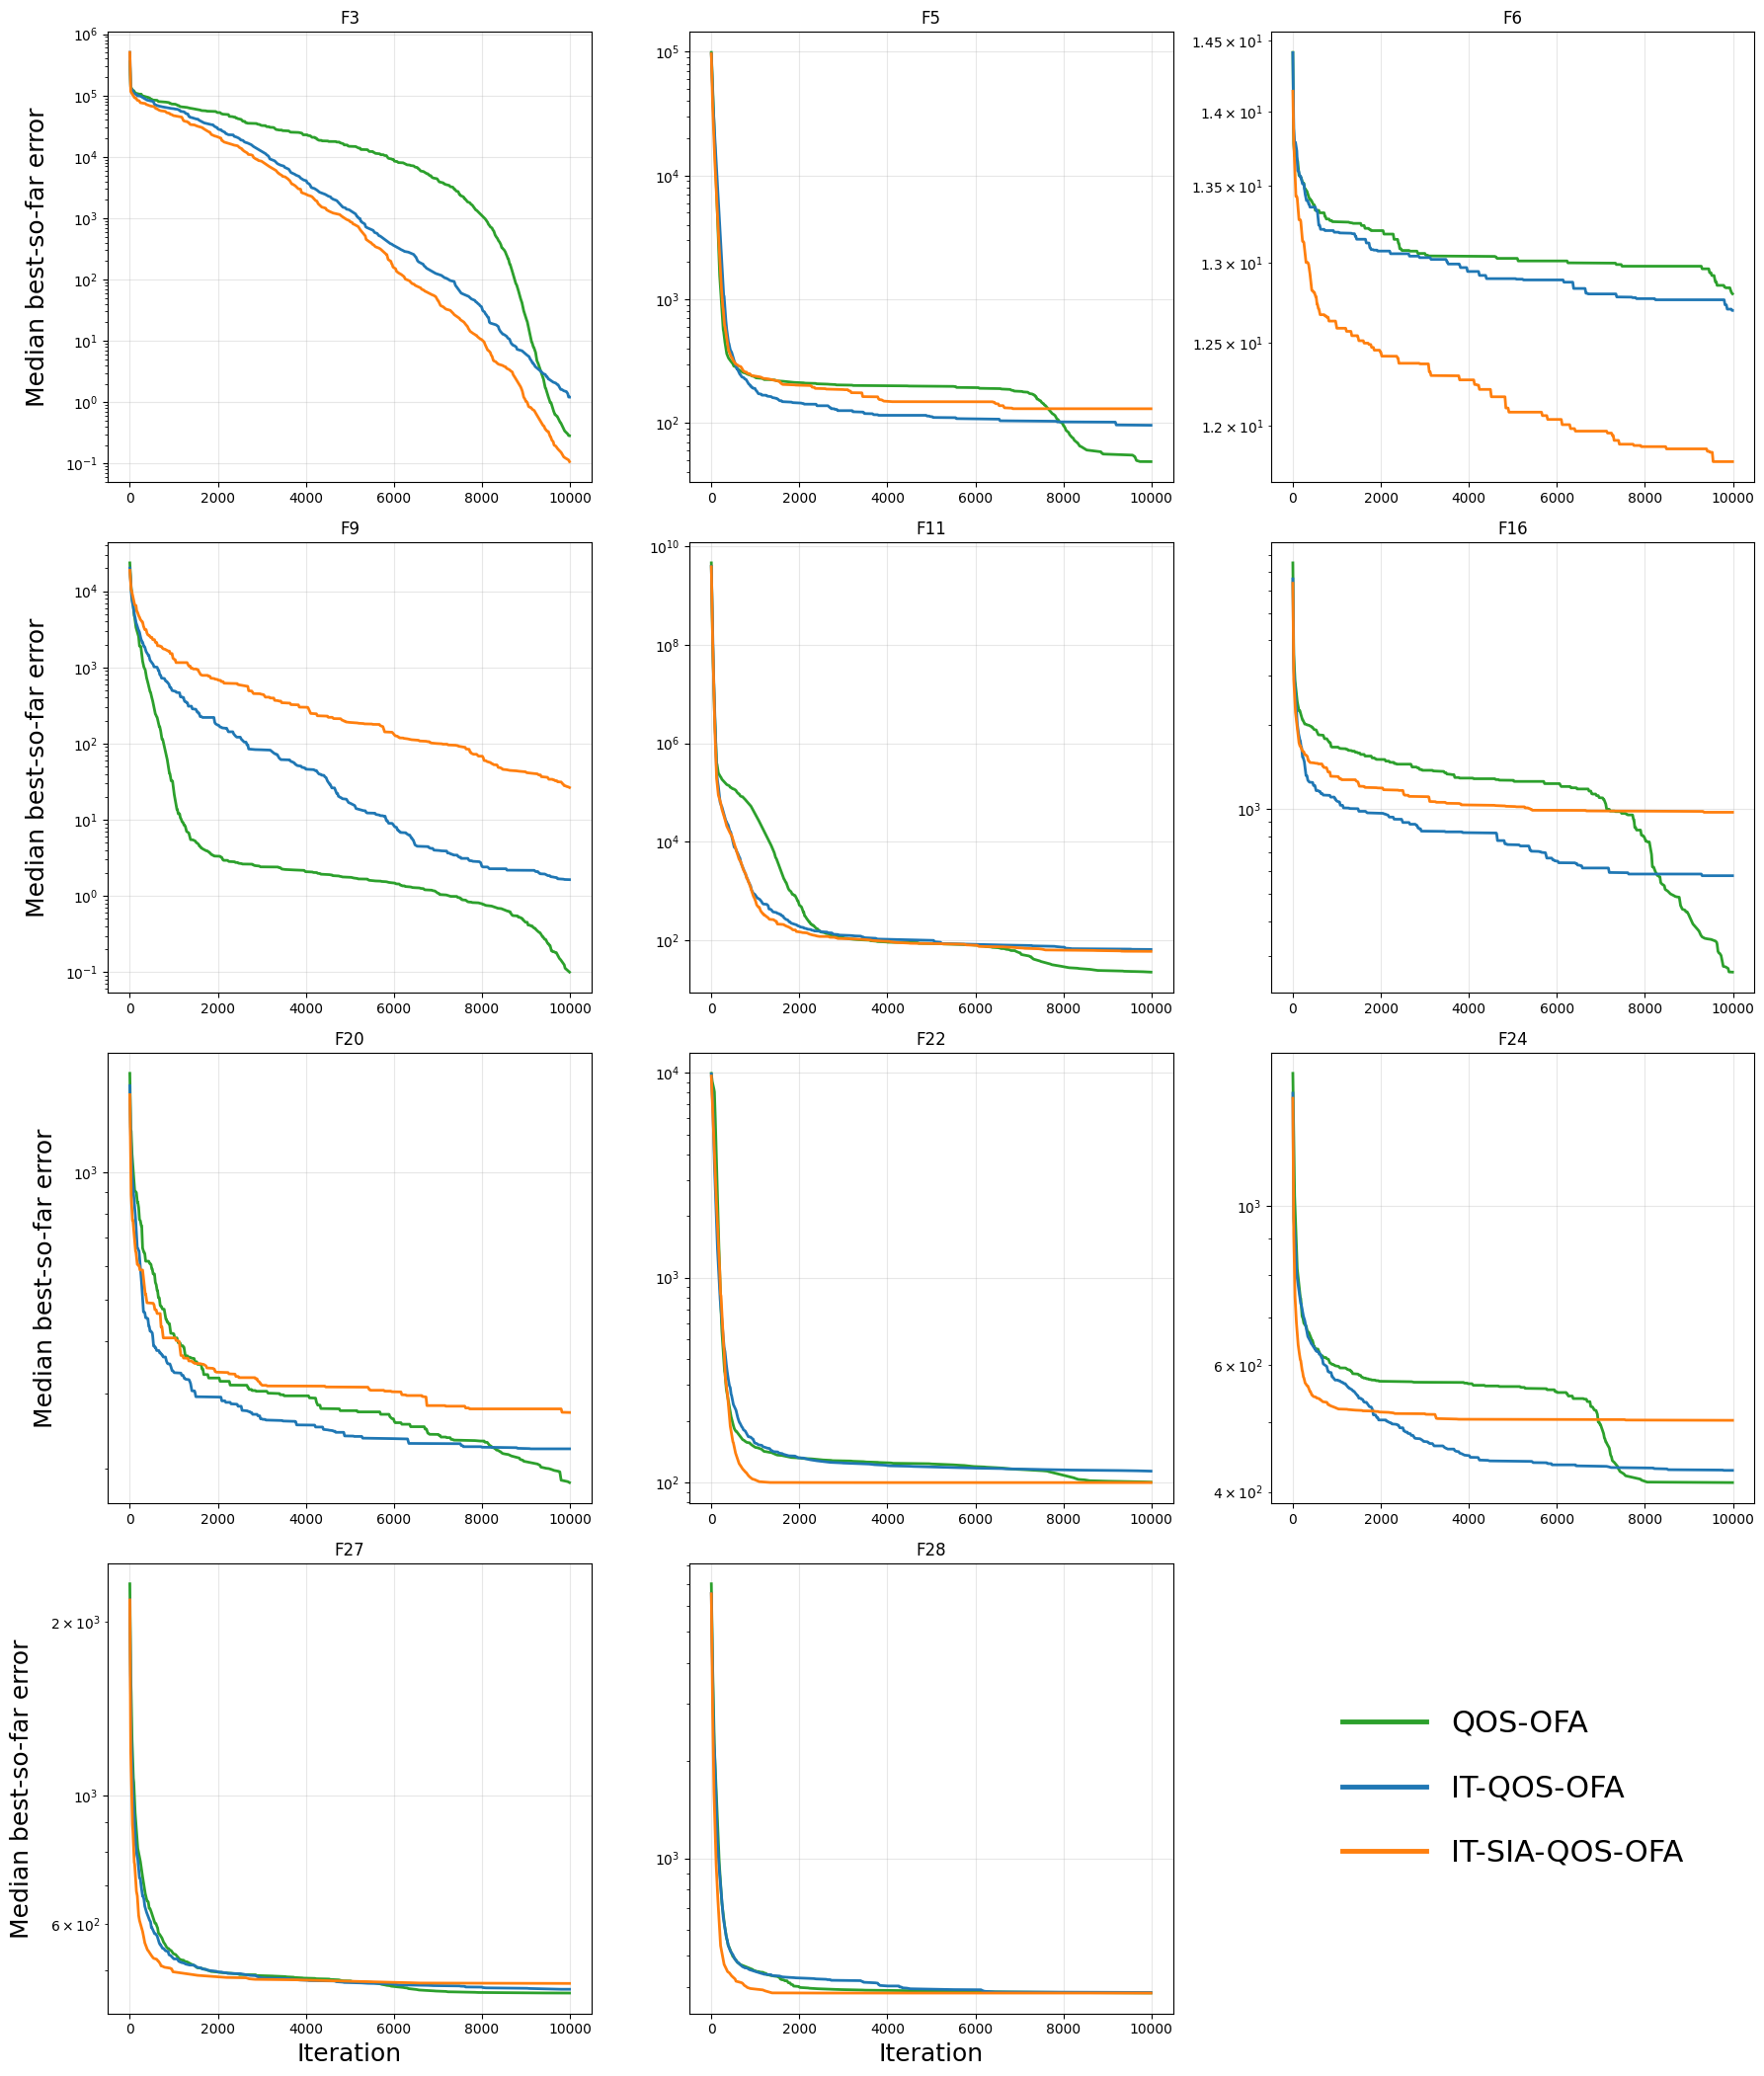

Saved SVG figure to: Figures\best_so_far_error_grid_11functions.svg


In [ ]:
# Best-so-far CEC error grid:
ALGORITHM_ORDER = ["QOS-OFA", "IT-QOS-OFA", "IT-SIA-QOS-OFA"]

# Enforced colors
ALGORITHM_COLORS = {"QOS-OFA": "tab:green","IT-QOS-OFA": "tab:blue","IT-SIA-QOS-OFA": "tab:orange"}
SVG_EVERY_N = 10

LEGEND_FONTSIZE = 22
LEGEND_LINEWIDTH = 3.5

# Font sizes
TITLE_FONTSIZE = 12
XLABEL_FONTSIZE = 18
YLABEL_FONTSIZE = 18
TICK_FONTSIZE = 10

# Keeps SVG text editable
plt.rcParams["svg.fonttype"] = "none"

# Helps simplify paths in SVG
plt.rcParams["path.simplify"] = True
plt.rcParams["path.simplify_threshold"] = 0.5


# Plotting
def plot_best_so_far_grid(combined_conv_df,*,output_path="Figures/best_so_far_error_grid_11functions.svg",cec_functions=None,use_log_y=True,include_iqr=False,nrows=4,ncols=3,figsize=(18, 22)):
    """
    Creates a 4x3 grid:
    - 11 subplots for CEC functions

    Each line shows the median best-so-far error.
    """

    base_metric = "best_error_so_far"
    metric_label = "Median best-so-far error"

    if cec_functions is None:
        cec_functions = sorted(int(x) for x in combined_conv_df["cec_func_num"].dropna().unique())

    n_funcs = len(cec_functions)
    total_slots = nrows * ncols

    if n_funcs > total_slots:
        raise ValueError(f"Not enough subplot slots: {total_slots} slots for {n_funcs} functions.")

    found_algorithms = set(combined_conv_df["algorithm_label"].unique())
    expected_algorithms = set(ALGORITHM_ORDER)

    if found_algorithms != expected_algorithms:
        raise ValueError(
            f"Unexpected algorithms found.\n"
            f"Expected: {sorted(expected_algorithms)}\n"
            f"Found: {sorted(found_algorithms)}"
        )

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for idx, cec_func_num in enumerate(cec_functions):
        ax = axes[idx]
        df_func = combined_conv_df[combined_conv_df["cec_func_num"] == cec_func_num].copy()

        if df_func.empty:
            ax.set_visible(False)
            continue

        x_col = pick_x_column(df_func)
        y_col, q25_col, q75_col = resolve_metric_columns(df_func, base_metric)

        for algorithm_label in ALGORITHM_ORDER:
            df_alg = df_func[df_func["algorithm_label"] == algorithm_label].copy()
            if df_alg.empty:
                continue

            df_alg = df_alg.sort_values(x_col)

            # Downsample only for SVG size/speed
            df_alg_svg = df_alg.iloc[::SVG_EVERY_N, :]
            x = df_alg_svg[x_col].to_numpy(dtype=float)
            y = df_alg_svg[y_col].to_numpy(dtype=float)

            if use_log_y:
                y = np.maximum(y, 1e-12)

            ax.plot(x,y,linewidth=2,color=ALGORITHM_COLORS[algorithm_label],label=algorithm_label)

            if include_iqr and q25_col is not None and q75_col is not None:
                q25 = df_alg_svg[q25_col].to_numpy(dtype=float)
                q75 = df_alg_svg[q75_col].to_numpy(dtype=float)

                if use_log_y:
                    q25 = np.maximum(q25, 1e-12)
                    q75 = np.maximum(q75, 1e-12)

                ax.fill_between(x,q25,q75,color=ALGORITHM_COLORS[algorithm_label],alpha=0.12)

        if use_log_y:
            ax.set_yscale("log")

        ax.set_title(f"F{cec_func_num}", fontsize=TITLE_FONTSIZE)

        if idx // ncols == nrows - 1:
            ax.set_xlabel("Iteration", fontsize=XLABEL_FONTSIZE)
        else:
            ax.set_xlabel("")

        if idx % ncols == 0:
            ax.set_ylabel(metric_label,fontsize=YLABEL_FONTSIZE,labelpad=12)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
        ax.grid(True, alpha=0.3)

    for j in range(n_funcs, total_slots):
        axes[j].axis("off")

    # Use the last empty subplot as the shared legend
    legend_ax = axes[total_slots - 1]
    legend_ax.axis("off")

    legend_handles = [
        Line2D([0],[0],color=ALGORITHM_COLORS[algorithm_label],linewidth=LEGEND_LINEWIDTH,label=algorithm_label)
        for algorithm_label in ALGORITHM_ORDER
    ]

    legend_ax.legend(handles=legend_handles,loc="center",frameon=False,fontsize=LEGEND_FONTSIZE,handlelength=2.8,labelspacing=1.2)
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight", format="svg")
    plt.show()
    print(f"Saved SVG figure to: {output_path}")

    return fig

cec_functions = sorted(int(x) for x in combined_conv_df["cec_func_num"].dropna().unique())
fig = plot_best_so_far_grid(combined_conv_df,output_path="Figures/best_so_far_error_grid_11functions.svg",cec_functions=cec_functions,use_log_y=True,include_iqr=False,nrows=4,ncols=3,figsize=(18, 22))

Maximum iteration in T=100 dataframe:
100

Max iteration per algorithm/function:
algorithm_label  cec_func_num
IT-QOS-OFA       3               100
                 5               100
                 6               100
                 9               100
                 11              100
                 16              100
                 20              100
                 22              100
                 24              100
                 27              100
                 28              100
IT-SIA-QOS-OFA   3               100
                 5               100
                 6               100
                 9               100
                 11              100
                 16              100
                 20              100
                 22              100
                 24              100
                 27              100
                 28              100
QOS-OFA          3               100
                 5               100
 

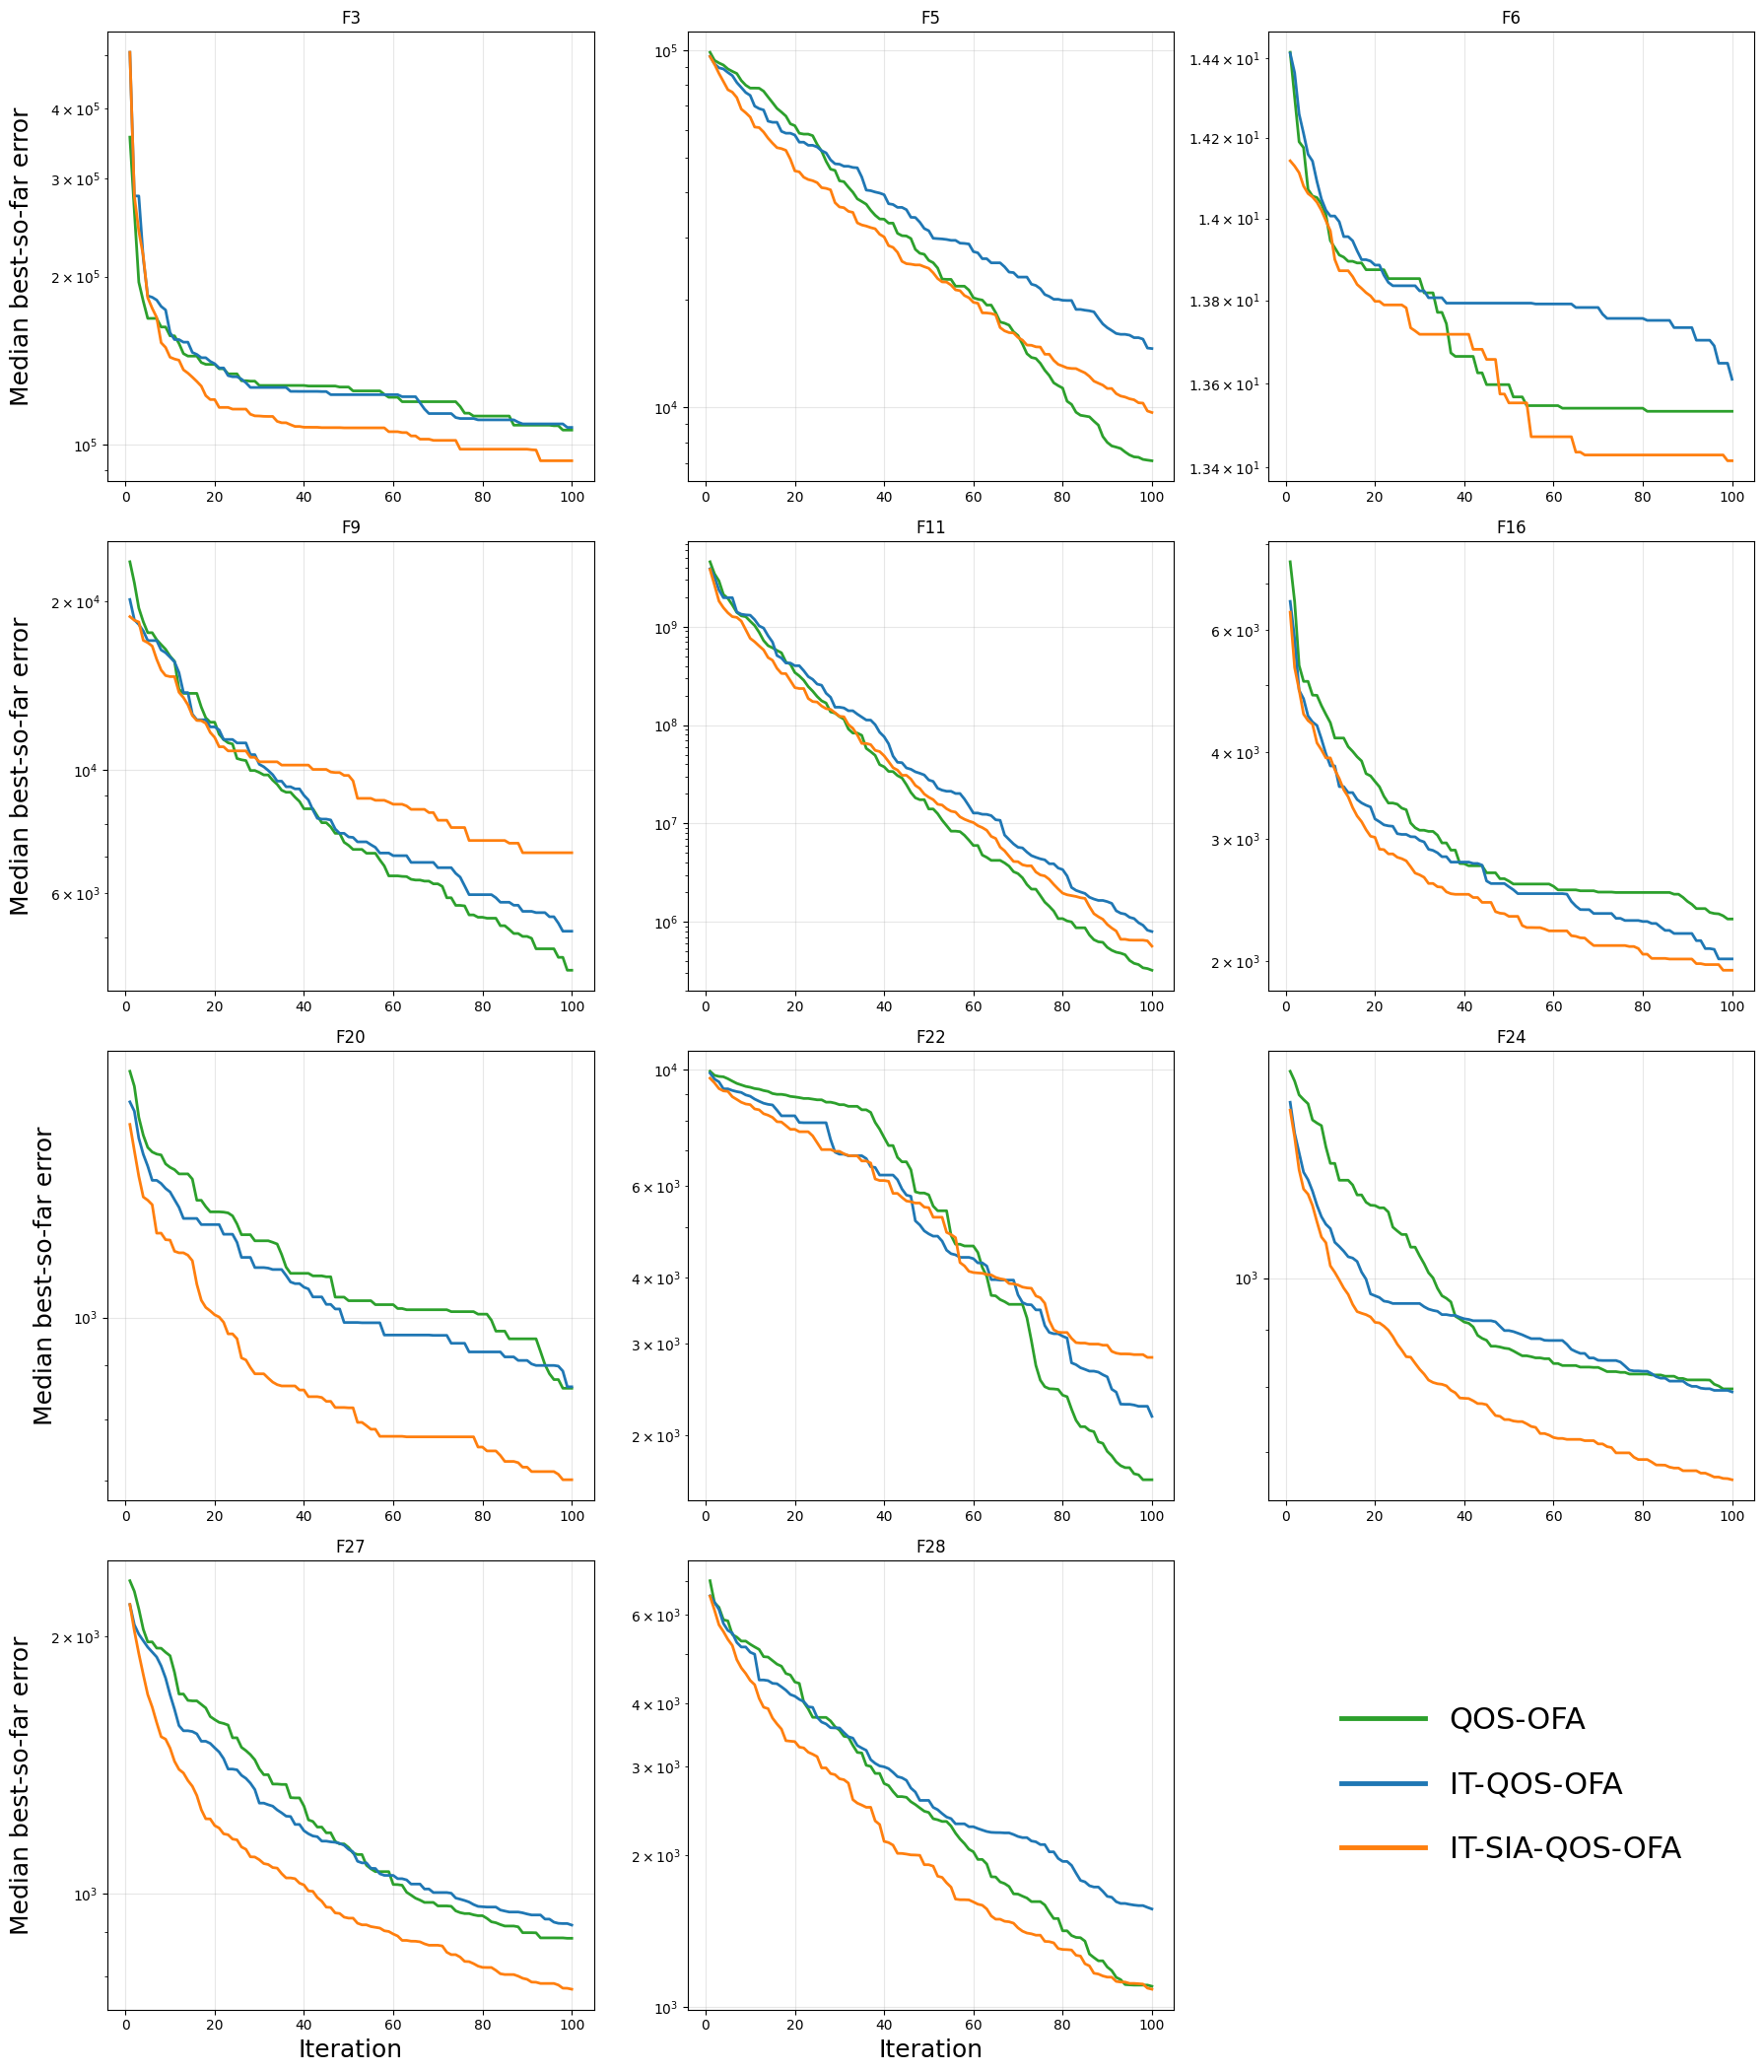

Saved SVG figure to: Figures\best_so_far_error_grid_11functions_100T.svg


In [9]:
# Best-so-far CEC error grid, T = 100:
ALGORITHM_ORDER = ["QOS-OFA", "IT-QOS-OFA", "IT-SIA-QOS-OFA"]

# Enforced colors
ALGORITHM_COLORS = {"QOS-OFA": "tab:green","IT-QOS-OFA": "tab:blue","IT-SIA-QOS-OFA": "tab:orange"}

algorithm_files_100 = {
    "QOS-OFA": "convergence_QOS_OFA_all_usable_cec_100T.xlsx",
    "IT-QOS-OFA": "convergence_IT_QOS_OFA_all_usable_cec_100T.xlsx",
    "IT-SIA-QOS-OFA": "convergence_IT_SIA_QOS_OFA_all_usable_cec_100T.xlsx",
}

OUTPUT_PATH = Path("Figures/best_so_far_error_grid_11functions_100T.svg")

BASE_METRIC = "best_error_so_far"
Y_COL = f"{BASE_METRIC}_median"
Q25_COL = f"{BASE_METRIC}_q25"
Q75_COL = f"{BASE_METRIC}_q75"

USE_LOG_Y = True
INCLUDE_IQR = False

# Font sizes
TITLE_FONTSIZE = 12
XLABEL_FONTSIZE = 18
YLABEL_FONTSIZE = 18
TICK_FONTSIZE = 10
LEGEND_FONTSIZE = 22
LEGEND_LINEWIDTH = 3.5

# Keeps SVG text editable
plt.rcParams["svg.fonttype"] = "none"

# Helps simplify paths in SVG
plt.rcParams["path.simplify"] = True
plt.rcParams["path.simplify_threshold"] = 0.5



# Loading T = 100 convergence files
parts = []

for algorithm_label, file_path in algorithm_files_100.items():
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"Could not find file: {file_path.resolve()}")

    df = pd.read_excel(file_path, sheet_name="convergence_all")
    df["algorithm_label"] = algorithm_label
    df["source_file"] = str(file_path)
    parts.append(df)

combined_conv_df_100 = pd.concat(parts, ignore_index=True)
combined_conv_df_100["cec_func_num"] = combined_conv_df_100["cec_func_num"].astype(int)

print("Maximum iteration in T=100 dataframe:")
print(combined_conv_df_100["iteration"].max())

print("\nMax iteration per algorithm/function:")
print(combined_conv_df_100.groupby(["algorithm_label", "cec_func_num"])["iteration"].max())


# Safety
if combined_conv_df_100["iteration"].max() != 100:
    raise ValueError(
        "The loaded dataframe is not a T=100 convergence dataframe.\n"
        f"Maximum iteration found: {combined_conv_df_100['iteration'].max()}\n"
        "This means the Excel files you loaded contain T=10000 data, "
        "or the files were overwritten / incorrectly exported.\n"
        "Regenerate the T=100 convergence Excel files before plotting."
    )

found_algorithms = set(combined_conv_df_100["algorithm_label"].unique())
expected_algorithms = set(ALGORITHM_ORDER)

if found_algorithms != expected_algorithms:
    raise ValueError(
        f"Unexpected algorithms found.\n"
        f"Expected: {sorted(expected_algorithms)}\n"
        f"Found: {sorted(found_algorithms)}"
    )

required_cols = ["algorithm_label", "cec_func_num", "objective_name", "iteration", Y_COL]

missing_cols = [c for c in required_cols if c not in combined_conv_df_100.columns]
if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}\n\n"
        f"Available best-so-far columns:\n"
        f"{[c for c in combined_conv_df_100.columns if BASE_METRIC in c]}"
    )

cec_functions_100 = sorted(int(x) for x in combined_conv_df_100["cec_func_num"].dropna().unique())

print("\nAlgorithms:", sorted(found_algorithms))
print("CEC functions:", cec_functions_100)
print("Plotted column:", Y_COL)


# Plotting
def plot_best_so_far_grid(df,*,output_path,cec_functions,use_log_y=True,include_iqr=False,nrows=4,ncols=3,figsize=(18, 22)):
    metric_label = "Median best-so-far error"
    total_slots = nrows * ncols

    if len(cec_functions) > total_slots:
        raise ValueError(f"Need at least {len(cec_functions)} subplot slots, "f"but only {total_slots} are available.")

    q25_col = Q25_COL if Q25_COL in df.columns else None
    q75_col = Q75_COL if Q75_COL in df.columns else None

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for idx, cec_func_num in enumerate(cec_functions):
        ax = axes[idx]
        df_func = df[df["cec_func_num"] == cec_func_num].copy()

        if df_func.empty:
            ax.axis("off")
            continue

        for algorithm_label in ALGORITHM_ORDER:
            df_alg = df_func[df_func["algorithm_label"] == algorithm_label].copy()
            if df_alg.empty:
                continue

            df_alg = df_alg.sort_values("iteration")
            x = df_alg["iteration"].to_numpy(dtype=float)
            y = df_alg[Y_COL].to_numpy(dtype=float)

            if use_log_y:
                y = np.maximum(y, 1e-12)

            ax.plot(x,y,linewidth=2,color=ALGORITHM_COLORS[algorithm_label],label=algorithm_label)

            if include_iqr and q25_col is not None and q75_col is not None:
                q25 = df_alg[q25_col].to_numpy(dtype=float)
                q75 = df_alg[q75_col].to_numpy(dtype=float)

                if use_log_y:
                    q25 = np.maximum(q25, 1e-12)
                    q75 = np.maximum(q75, 1e-12)

                ax.fill_between(x,q25,q75,color=ALGORITHM_COLORS[algorithm_label],alpha=0.12)

        if use_log_y:
            ax.set_yscale("log")

        ax.set_title(f"F{cec_func_num}", fontsize=TITLE_FONTSIZE)

        if idx // ncols == nrows - 1:
            ax.set_xlabel("Iteration", fontsize=XLABEL_FONTSIZE)
        else:
            ax.set_xlabel("")

        if idx % ncols == 0:
            ax.set_ylabel(metric_label,fontsize=YLABEL_FONTSIZE,labelpad=12)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
        ax.grid(True, alpha=0.3)

    for j in range(len(cec_functions), total_slots):
        axes[j].axis("off")

    # Use the last empty subplot as the shared legend
    legend_ax = axes[total_slots - 1]
    legend_ax.axis("off")

    legend_handles = [
        Line2D([0],[0],color=ALGORITHM_COLORS[algorithm_label],linewidth=LEGEND_LINEWIDTH,label=algorithm_label)
        for algorithm_label in ALGORITHM_ORDER
    ]

    legend_ax.legend(handles=legend_handles,loc="center",frameon=False,fontsize=LEGEND_FONTSIZE,handlelength=2.8,labelspacing=1.2)
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight", format="svg")
    plt.show()
    print(f"Saved SVG figure to: {output_path}")

    return fig

fig = plot_best_so_far_grid(combined_conv_df_100,output_path=OUTPUT_PATH,cec_functions=cec_functions_100,use_log_y=USE_LOG_Y,include_iqr=INCLUDE_IQR,nrows=4,ncols=3,figsize=(18, 22))

In [ ]:
# Safety
if "combined_conv_df_100" not in globals():
    raise NameError("combined_conv_df_100 does not exist. Load the T=100 files first.")

max_iter = combined_conv_df_100["iteration"].max()

if max_iter != 100:
    raise ValueError(f"combined_conv_df_100 is not T=100 data. Max iteration found: {max_iter}")

print("Confirmed: using T=100 dataframe.")


# Final best-so-far table
required_cols = ["algorithm_label", "cec_func_num", "objective_name", "iteration", "best_error_so_far_median"]

missing_cols = [c for c in required_cols if c not in combined_conv_df_100.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# Final iteration
df_final_100 = combined_conv_df_100[combined_conv_df_100["iteration"] == 100].copy()

print("Rows at iteration 100:", len(df_final_100))
print("Algorithms:", sorted(df_final_100["algorithm_label"].unique()))
print("Functions:", sorted(df_final_100["cec_func_num"].unique()))

# Long table
final_best_so_far_100_long = df_final_100[required_cols].sort_values(["cec_func_num", "algorithm_label"]).reset_index(drop=True)

# Appendix table
final_best_so_far_100_table = final_best_so_far_100_long.pivot_table(
    index=["cec_func_num", "objective_name"],columns="algorithm_label",values="best_error_so_far_median",aggfunc="first"
).reset_index()

final_best_so_far_100_table = final_best_so_far_100_table.rename(columns={"cec_func_num": "Function","objective_name": "Objective"})

preferred_order = ["Function", "Objective", "QOS-OFA", "IT-QOS-OFA", "IT-SIA-QOS-OFA"]

final_best_so_far_100_table = final_best_so_far_100_table[
    [c for c in preferred_order if c in final_best_so_far_100_table.columns]
]

display(final_best_so_far_100_table)


# Saving LaTeX table
OUTPUT_LATEX = Path("appendix_final_best_so_far_T100.tex")

latex_table = final_best_so_far_100_table.copy()

# Function numbers as F_i
latex_table["Function"] = latex_table["Function"].apply(lambda x: f"$F_{{{int(x)}}}$")

# Numeric columns
for col in latex_table.columns:
    if col not in ["Function", "Objective"]:
        latex_table[col] = latex_table[col].apply(lambda x: f"{x:.6g}" if pd.notna(x) else "")

latex_code = latex_table.to_latex(
    index=False,
    escape=False,
    caption=("Final median best-so-far CEC error after \(T=100\) iterations " "for the selected benchmark functions."),
    label="tab:appendix_final_best_so_far_T100",
    column_format="llccc"
)

with open(OUTPUT_LATEX, "w", encoding="utf-8") as f:
    f.write(latex_code)

print(f"Saved T=100 LaTeX table to: {OUTPUT_LATEX}")
print(latex_code)


# Saving Excel
OUTPUT_EXCEL = Path("appendix_final_best_so_far_T100.xlsx")

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    final_best_so_far_100_long.to_excel(writer,sheet_name="long_table",index=False)
    final_best_so_far_100_table.to_excel(writer,sheet_name="appendix_table",index=False)

print(f"Saved T=100 appendix table to: {OUTPUT_EXCEL}")

Confirmed: using T=100 dataframe.
Rows at iteration 100: 33
Algorithms: ['IT-QOS-OFA', 'IT-SIA-QOS-OFA', 'QOS-OFA']
Functions: [np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(16), np.int64(20), np.int64(22), np.int64(24), np.int64(27), np.int64(28)]


algorithm_label,Function,Objective,QOS-OFA,IT-QOS-OFA,IT-SIA-QOS-OFA
0,3,CEC Zakharov,106144.625000,107301.512337,93500.539062
1,5,CEC Rastrigin,7096.724121,14632.709378,9688.290039
2,6,CEC Expanded Scaffer's F6,13.533142,13.609545,13.416016
3,9,CEC Levy,4372.805664,5135.909129,7098.082031
4,11,CEC Hybrid Function 1,322065.562500,797463.116858,566165.375000
5,16,CEC Hybrid Function 6,2300.233154,2014.659654,1940.355713
6,20,CEC Hybrid Function 10,856.702393,859.423013,701.403320
7,22,CEC Composition Function 2,1646.357910,2175.327407,2820.397949
8,24,CEC Composition Function 4,796.688721,791.786229,661.264038
9,27,CEC Composition Function 7,885.977051,918.124987,772.270142


Saved T=100 LaTeX table to: appendix_final_best_so_far_T100.tex
\begin{table}
\caption{Final median best-so-far CEC error after \(T=100\) iterations for the selected benchmark functions.}
\label{tab:appendix_final_best_so_far_T100}
\begin{tabular}{llccc}
\toprule
Function & Objective & QOS-OFA & IT-QOS-OFA & IT-SIA-QOS-OFA \\
\midrule
$F_{3}$ & CEC Zakharov & 106145 & 107302 & 93500.5 \\
$F_{5}$ & CEC Rastrigin & 7096.72 & 14632.7 & 9688.29 \\
$F_{6}$ & CEC Expanded Scaffer's F6 & 13.5331 & 13.6095 & 13.416 \\
$F_{9}$ & CEC Levy & 4372.81 & 5135.91 & 7098.08 \\
$F_{11}$ & CEC Hybrid Function 1 & 322066 & 797463 & 566165 \\
$F_{16}$ & CEC Hybrid Function 6 & 2300.23 & 2014.66 & 1940.36 \\
$F_{20}$ & CEC Hybrid Function 10 & 856.702 & 859.423 & 701.403 \\
$F_{22}$ & CEC Composition Function 2 & 1646.36 & 2175.33 & 2820.4 \\
$F_{24}$ & CEC Composition Function 4 & 796.689 & 791.786 & 661.264 \\
$F_{27}$ & CEC Composition Function 7 & 885.977 & 918.125 & 772.27 \\
$F_{28}$ & CEC Compositio

Available algorithms:
['QOS-OFA' 'IT-QOS-OFA' 'IT-SIA-QOS-OFA']

Selected functions:
[np.int64(3), np.int64(5), np.int64(6), np.int64(9), np.int64(11), np.int64(16), np.int64(20), np.int64(22), np.int64(24), np.int64(27), np.int64(28)]


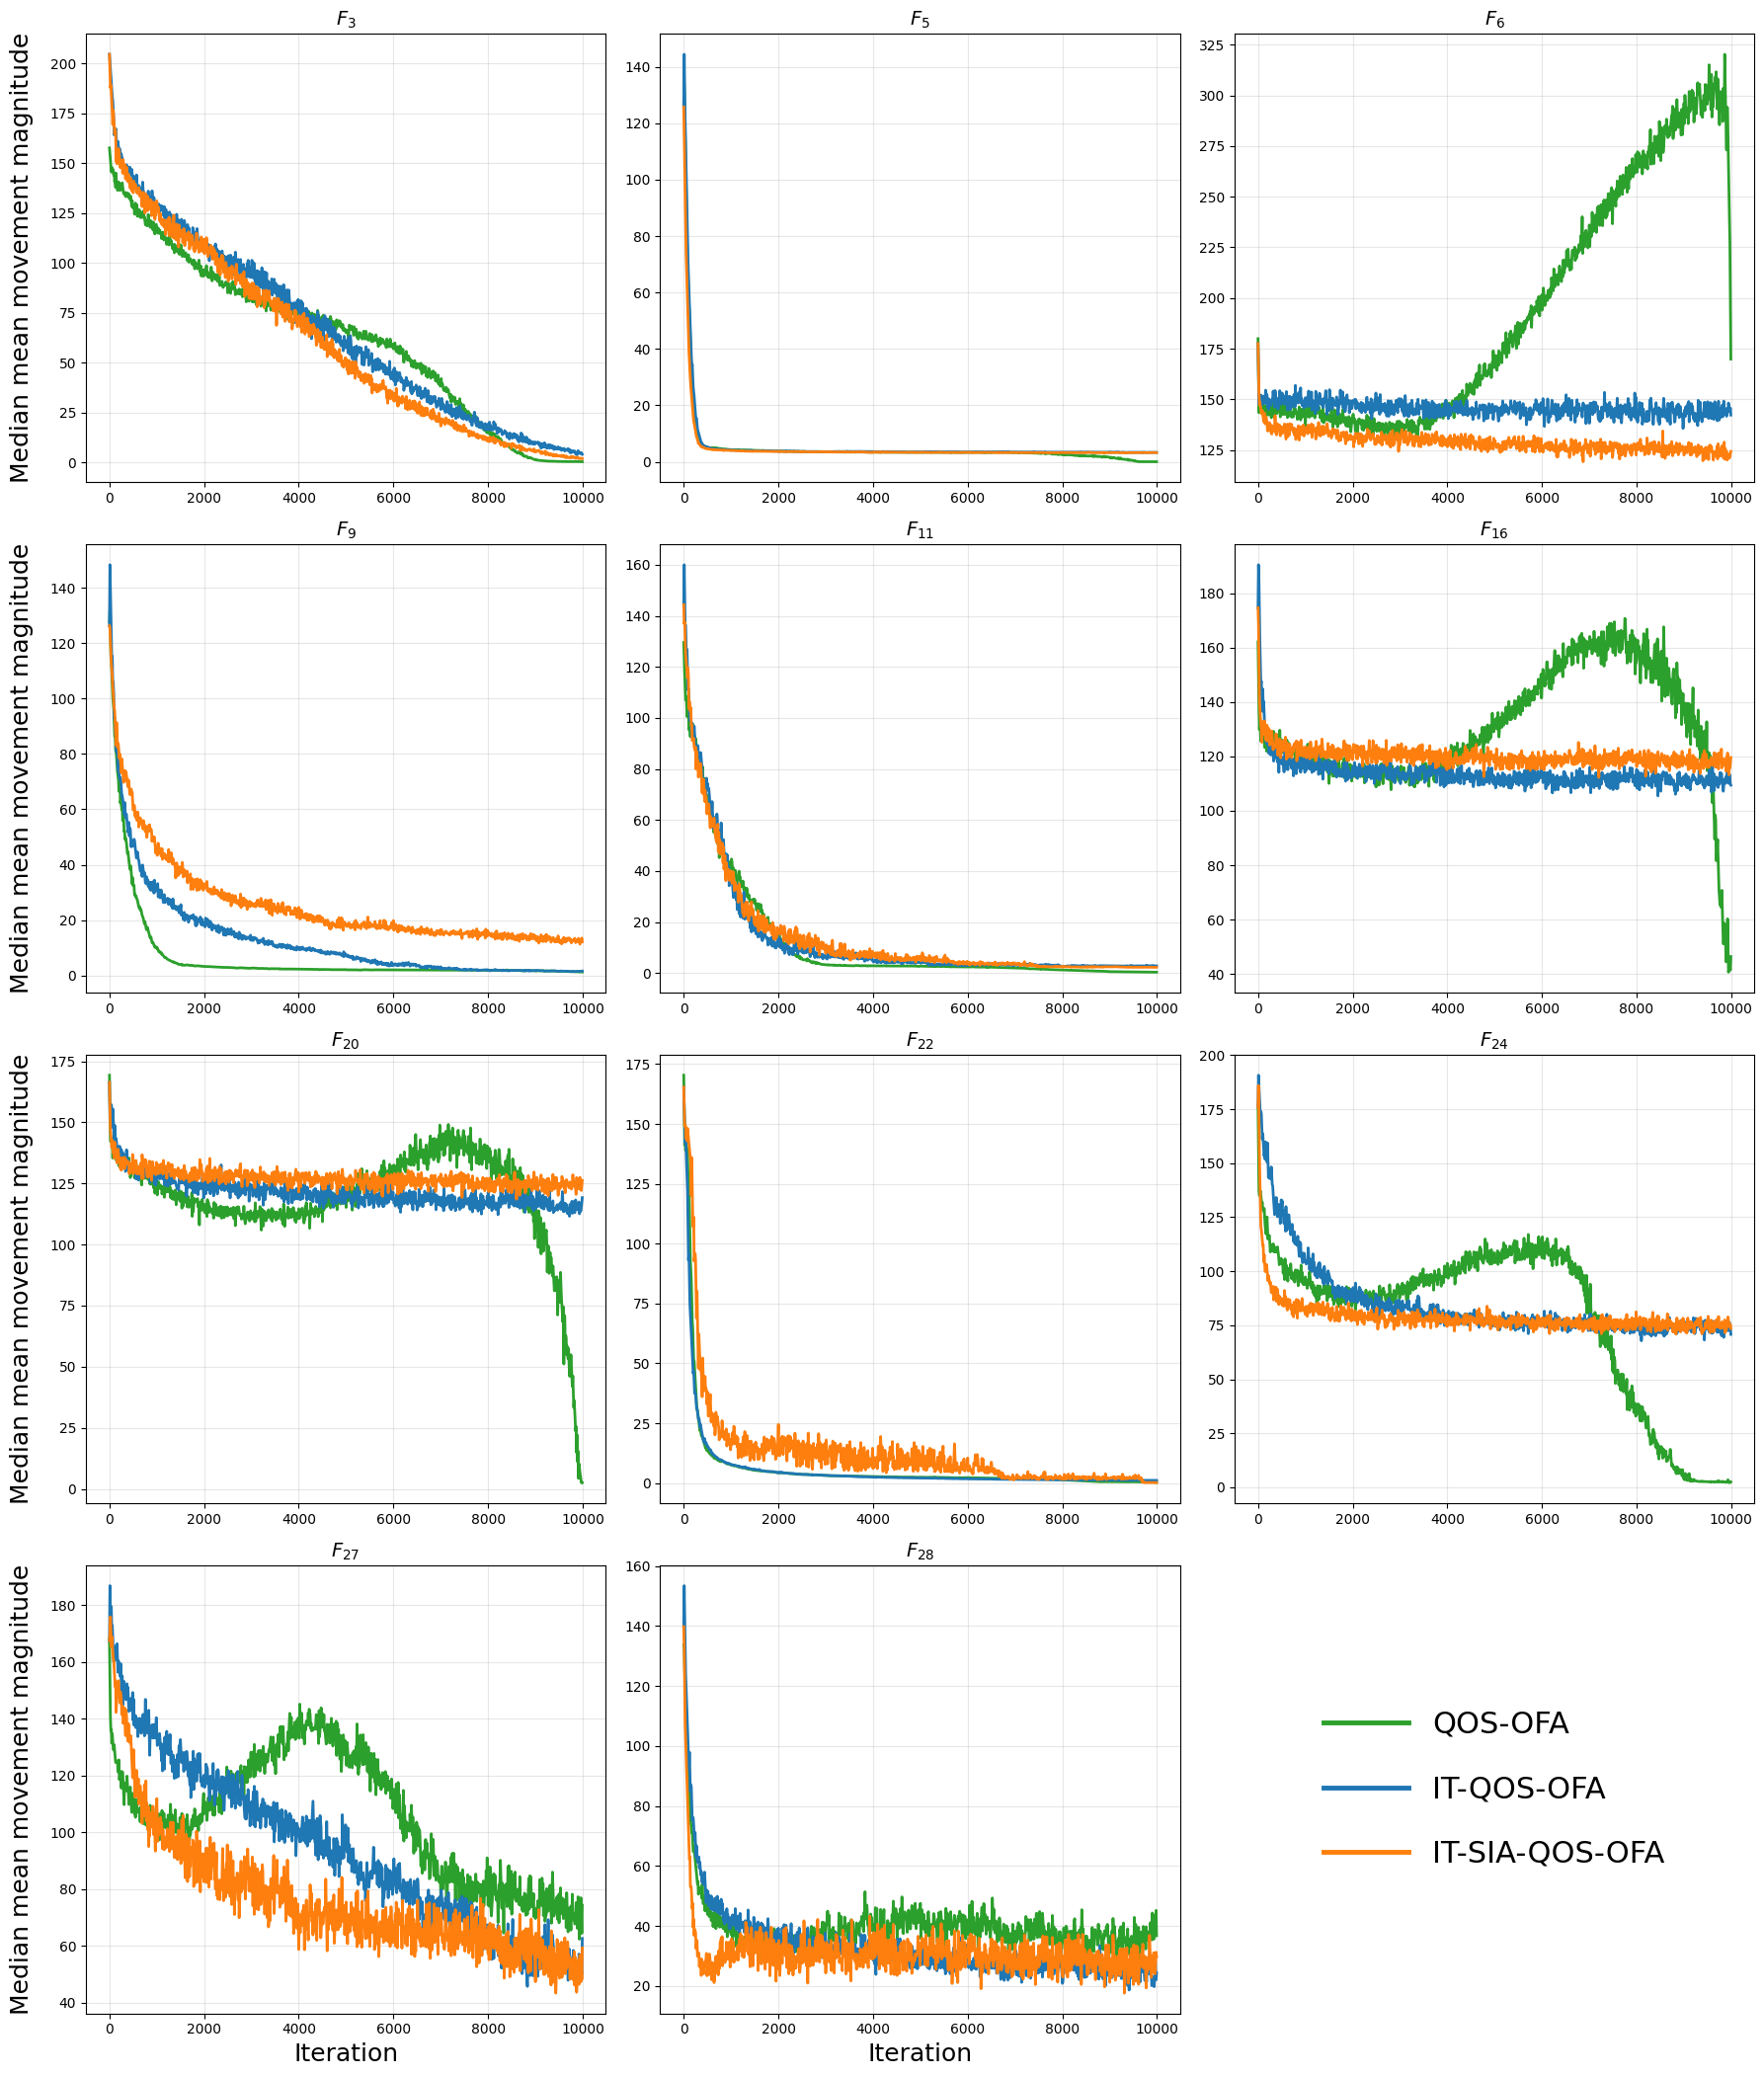

Saved SVG figure: Figures\mean_movement_magnitude_grid_11functions.svg


In [10]:
# Median mean movement magnitude grid
# QOS-OFA vs IT-QOS-OFA vs IT-SIA-QOS-OFA
INPUT_FILES = {
    "QOS-OFA": Path("analysis_exports/convergence_QOS_OFA_all_usable_cec.xlsx"),
    "IT-QOS-OFA": Path("analysis_exports/convergence_IT_QOS_OFA_all_usable_cec.xlsx"),
    "IT-SIA-QOS-OFA": Path("analysis_exports/convergence_IT_SIA_QOS_OFA_all_usable_cec.xlsx"),
}


ALGORITHM_ORDER = ["QOS-OFA", "IT-QOS-OFA", "IT-SIA-QOS-OFA"]

ALGORITHM_COLORS = {"QOS-OFA": "tab:green", "IT-QOS-OFA": "tab:blue", "IT-SIA-QOS-OFA": "tab:orange"}

SELECTED_CEC_FUNC_NUMS = [3, 5, 6, 9, 11, 16, 20, 22, 24, 27, 28]

Y_COL = "mean_step_norm_median"

OUTPUT_DIR = Path("Figures")
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "mean_movement_magnitude_grid_11functions.svg"

SVG_EVERY_N = 10

# Font sizes
TITLE_FONTSIZE = 14
XLABEL_FONTSIZE = 18
YLABEL_FONTSIZE = 18
TICK_FONTSIZE = 10
LEGEND_FONTSIZE = 22
LEGEND_LINEWIDTH = 3.5
USE_LOG_Y = False

# Keeps SVG text editable
plt.rcParams["svg.fonttype"] = "none"

# Helps simplify paths in SVG
plt.rcParams["path.simplify"] = True
plt.rcParams["path.simplify_threshold"] = 0.5

# Loading convergance data from Excel files

dfs = []
for algorithm_label, path in INPUT_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Could not find file: {path}")

    df_alg = pd.read_excel(path, sheet_name="convergence_all")
    df_alg["cec_func_num"] = df_alg["cec_func_num"].astype(int)
    if "algorithm_label" in df_alg.columns:
        df_alg = df_alg[df_alg["algorithm_label"] == algorithm_label].copy()
    else:
        df_alg["algorithm_label"] = algorithm_label

    df_alg = df_alg[df_alg["cec_func_num"].isin(SELECTED_CEC_FUNC_NUMS)].copy()
    if Y_COL not in df_alg.columns:
        raise ValueError(
            f"{algorithm_label}: missing required column '{Y_COL}'.\n\n"
            f"Available movement columns:\n"
            f"{[c for c in df_alg.columns if 'step' in c.lower() or 'movement' in c.lower()]}"
        )

    dfs.append(df_alg)
combined_df = pd.concat(dfs, ignore_index=True)



required_cols = ["algorithm_label", "cec_func_num", "objective_name", "iteration", Y_COL]
missing_cols = [c for c in required_cols if c not in combined_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

found_algorithms = set(combined_df["algorithm_label"].unique())
expected_algorithms = set(ALGORITHM_ORDER)

if found_algorithms != expected_algorithms:
    raise ValueError(f"Unexpected algorithms found.\n"f"Expected: {sorted(expected_algorithms)}\n"f"Found: {sorted(found_algorithms)}")

print("Available algorithms:")
print(combined_df["algorithm_label"].unique())

print("\nSelected functions:")
print(sorted(combined_df["cec_func_num"].unique()))


# Plotting
nrows = 4
ncols = 3
total_slots = nrows * ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 22))
axes = axes.flatten()

for plot_idx, cec_func_num in enumerate(SELECTED_CEC_FUNC_NUMS):
    ax = axes[plot_idx]
    df_func_all = combined_df[combined_df["cec_func_num"] == cec_func_num].copy()
    if df_func_all.empty:
        ax.set_title(f"$F_{{{cec_func_num}}}$: missing", fontsize=TITLE_FONTSIZE)
        ax.axis("off")
        continue

    for algorithm_label in ALGORITHM_ORDER:
        df_plot = df_func_all[ df_func_all["algorithm_label"] == algorithm_label].copy()
        if df_plot.empty:
            continue

        df_plot = df_plot.sort_values("iteration")
        # Downsample only for SVG size
        df_plot_svg = df_plot.iloc[::SVG_EVERY_N, :]
        ax.plot(
            df_plot_svg["iteration"],
            df_plot_svg[Y_COL],
            color=ALGORITHM_COLORS[algorithm_label],
            linewidth=2.0,
            label=algorithm_label,
        )

    ax.set_title(f"$F_{{{cec_func_num}}}$",fontsize=TITLE_FONTSIZE)
    if plot_idx // ncols == nrows - 1:
        ax.set_xlabel("Iteration", fontsize=XLABEL_FONTSIZE)
    else:
        ax.set_xlabel("")

    if plot_idx % ncols == 0:
        ax.set_ylabel("Median mean movement magnitude", fontsize=YLABEL_FONTSIZE, labelpad=12)
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    ax.grid(True, alpha=0.3)

    if USE_LOG_Y:
        ax.set_yscale("log")



# Legend plotting
legend_ax = axes[-1]
legend_ax.axis("off")

legend_handles = [Line2D([0], [0], color=ALGORITHM_COLORS[algorithm_label], linewidth=LEGEND_LINEWIDTH, label=algorithm_label)
    for algorithm_label in ALGORITHM_ORDER
]

legend_ax.legend(handles=legend_handles, loc="center", fontsize=LEGEND_FONTSIZE, frameon=False, handlelength=2.8, labelspacing=1.2)

# Remove unused axes if any
for ax in axes[len(SELECTED_CEC_FUNC_NUMS) + 1:]:
    ax.axis("off")

fig.tight_layout(rect=[0, 0.02, 1, 0.98])
fig.savefig(OUTPUT_PATH, format="svg", bbox_inches="tight")
plt.show()

print(f"Saved SVG figure: {OUTPUT_PATH}")